# Bitcoin Options Implied Distribution Analysis (IBIT)

This notebook analyzes IBIT (iShares Bitcoin Trust ETF) options data to extract implied volatility (IV) and the volatility smile, then uses this to derive a market-implied probability distribution for Bitcoin prices. We account for IBIT's BTC-per-share ratio to convert IBIT share prices to Bitcoin prices. We generate 10,000 simulated price paths based on this distribution.


## Step 1: Fetch IBIT Options Data and BTC-per-Share Ratio

Fetch current IBIT (iShares Bitcoin Trust ETF) price and options chain data. Also fetch the BTC-per-share ratio to convert IBIT share prices to Bitcoin prices.


In [285]:
# ============================================================================
# IMPORT LIBRARIES
# ============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.optimize import minimize
from scipy.interpolate import interp1d, UnivariateSpline
from scipy.stats import norm
import warnings
warnings.filterwarnings('ignore')

# Note: yfinance is no longer needed - data is loaded from JSON files

# ============================================================================
# DEBUG CONFIGURATION
# ============================================================================
DEBUG = True  # Set to True to enable debug logging and verbose output

print("Libraries imported successfully.")
if DEBUG:
    print("DEBUG MODE: Enabled")


Libraries imported successfully.
DEBUG MODE: Enabled


In [286]:
# ============================================================================
# LOAD IBIT DATA FROM JSON FILES
# ============================================================================

import json
import os
from datetime import datetime

print("Loading IBIT (iShares Bitcoin Trust ETF) data from JSON files...")

# Load IBIT data from JSON file (created by fetch_data.py)
ibit_data_file = 'output/ibit_data.json'

if not os.path.exists(ibit_data_file):
    raise FileNotFoundError(
        f"Error: {ibit_data_file} not found. "
        f"Please run 'python fetch_data.py' first to generate the data file."
    )

with open(ibit_data_file, 'r') as f:
    ibit_data = json.load(f)

# Extract data from JSON
CURRENT_IBIT_PRICE = ibit_data.get('current_price')
BTC_PER_SHARE = ibit_data.get('btc_per_share', 22.69 / 40000)
CURRENT_BTC_PRICE = ibit_data.get('btc_price')
expirations = ibit_data.get('expirations', [])
ibit_options_data = ibit_data.get('options_data', {})

# Fallback calculations if needed
if CURRENT_IBIT_PRICE is None:
    CURRENT_IBIT_PRICE = 40.0
    print(f"⚠ Warning: IBIT price not found in JSON, using fallback: ${CURRENT_IBIT_PRICE:,.2f}")

if CURRENT_BTC_PRICE is None and CURRENT_IBIT_PRICE:
    CURRENT_BTC_PRICE = CURRENT_IBIT_PRICE / BTC_PER_SHARE
    print(f"⚠ Warning: BTC price not found in JSON, calculating from IBIT price")

if BTC_PER_SHARE is None:
    BTC_PER_SHARE = 22.69 / 40000
    print(f"⚠ Warning: BTC_PER_SHARE not found in JSON, using default: {BTC_PER_SHARE:.6f}")

print(f"✓ Current IBIT Share Price: ${CURRENT_IBIT_PRICE:,.2f}")
print(f"✓ BTC per IBIT Share: {BTC_PER_SHARE:.6f} BTC")
print(f"✓ Current Bitcoin Price: ${CURRENT_BTC_PRICE:,.2f}")

if len(expirations) > 0:
    print(f"\n✓ Found {len(expirations)} IBIT option expiration dates")
    print(f"Available expirations: {expirations[:5]}")  # Show first 5
else:
    print("\n⚠ No IBIT options data found in JSON file")
    print("We'll use synthetic options data")

# Summary
print(f"\n" + "="*70)
print("IBIT CONFIGURATION SUMMARY")
print("="*70)
print(f"Data Source: {ibit_data_file}")
print(f"Data Timestamp: {ibit_data.get('timestamp', 'N/A')}")
print(f"IBIT Share Price: ${CURRENT_IBIT_PRICE:,.2f}")
print(f"BTC per IBIT Share: {BTC_PER_SHARE:.6f} BTC")
print(f"Current Bitcoin Price: ${CURRENT_BTC_PRICE:,.2f}")
print(f"Conversion Factor: 1 IBIT share = {BTC_PER_SHARE:.6f} BTC")
print(f"  (IBIT strike prices will be converted to BTC-equivalent using this ratio)")
print("="*70)


Loading IBIT (iShares Bitcoin Trust ETF) data from JSON files...
✓ Current IBIT Share Price: $49.71
✓ BTC per IBIT Share: 0.000567 BTC
✓ Current Bitcoin Price: $87,310.73

✓ Found 19 IBIT option expiration dates
Available expirations: ['2025-12-19', '2025-12-26', '2025-12-31', '2026-01-02', '2026-01-09']

IBIT CONFIGURATION SUMMARY
Data Source: ibit_data.json
Data Timestamp: 2025-12-16T20:18:32.458417
IBIT Share Price: $49.71
BTC per IBIT Share: 0.000567 BTC
Current Bitcoin Price: $87,310.73
Conversion Factor: 1 IBIT share = 0.000567 BTC
  (IBIT strike prices will be converted to BTC-equivalent using this ratio)


In [287]:
# ============================================================================
# UTILITY FUNCTIONS - Black-Scholes, IV Calculation, Option Processing
# ============================================================================

def black_scholes_call(S, K, T, r, sigma):
    """Black-Scholes call option price"""
    if T <= 0 or sigma <= 0 or K <= 0:
        return max(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return S * norm.cdf(d1) - K * np.exp(-r * T) * norm.cdf(d2)

def black_scholes_put(S, K, T, r, sigma):
    """Black-Scholes put option price"""
    if T <= 0 or sigma <= 0 or K <= 0:
        return max(K - S, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    return K * np.exp(-r * T) * norm.cdf(-d2) - S * norm.cdf(-d1)

def black_scholes_price(S, K, T, r, sigma, option_type='call'):
    """Black-Scholes option pricing formula (unified)"""
    if option_type == 'call':
        return black_scholes_call(S, K, T, r, sigma)
    else:
        return black_scholes_put(S, K, T, r, sigma)

def black_scholes_vega(S, K, T, r, sigma):
    """Vega: derivative of BS price w.r.t. volatility"""
    if T <= 0 or sigma <= 0:
        return 0
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * T) / (sigma * np.sqrt(T))
    return S * norm.pdf(d1) * np.sqrt(T)

def calculate_implied_volatility(option_price, S, K, T, r, option_type='call', method='newton'):
    """
    Calculate implied volatility from option price using Black-Scholes inversion.
    
    Parameters:
    - option_price: Market price of the option
    - S: Current stock/asset price
    - K: Strike price
    - T: Time to expiration (years)
    - r: Risk-free rate (annual)
    - option_type: 'call' or 'put'
    - method: 'newton' (Newton-Raphson) or 'bisection'
    
    Returns:
    - Implied volatility (annualized)
    """
    # Handle edge cases
    if option_price <= 0:
        return 0.0
    
    # Intrinsic value check
    intrinsic = max(S - K, 0) if option_type == 'call' else max(K - S, 0)
    if option_price < intrinsic:
        return 0.0
    
    if T <= 0:
        return 0.0
    
    # Initial guess for volatility
    sigma = 0.3  # Start with 30%
    
    if method == 'newton':
        # Newton-Raphson method
        max_iterations = 100
        tolerance = 1e-6
        
        for i in range(max_iterations):
            price_est = black_scholes_price(S, K, T, r, sigma, option_type)
            vega = black_scholes_vega(S, K, T, r, sigma)
            
            if vega < 1e-10:  # Avoid division by zero
                break
            
            error = price_est - option_price
            if abs(error) < tolerance:
                break
            
            sigma = sigma - error / vega
            sigma = max(0.001, min(sigma, 5.0))
        
        return sigma
    
    else:  # bisection method
        sigma_low = 0.001
        sigma_high = 5.0
        max_iterations = 100
        tolerance = 1e-6
        
        for i in range(max_iterations):
            sigma = (sigma_low + sigma_high) / 2
            price_est = black_scholes_price(S, K, T, r, sigma, option_type)
            error = price_est - option_price
            
            if abs(error) < tolerance:
                break
            
            if error > 0:
                sigma_high = sigma
            else:
                sigma_low = sigma
        
        return sigma

def get_option_price(bid, ask, last_price):
    """
    Get option price from bid/ask or last price.
    Returns: (price, source) where source is 'mid' or 'last'
    """
    if bid > 0 and ask > 0:
        return (bid + ask) / 2, 'mid'
    elif last_price > 0:
        return last_price, 'last'
    else:
        return None, None

def process_option_for_iv(option_dict, current_price, strike, time_to_expiry, risk_free_rate, option_type):
    """
    Process a single option dictionary to calculate IV.
    
    Returns: dict with IV data or None if invalid
    """
    bid = option_dict.get('bid', 0) or 0
    ask = option_dict.get('ask', 0) or 0
    last_price = option_dict.get('lastPrice', 0) or 0
    
    option_price, price_source = get_option_price(bid, ask, last_price)
    if option_price is None:
        return None
    
    iv = calculate_implied_volatility(
        option_price, current_price, strike, time_to_expiry, 
        risk_free_rate, option_type=option_type, method='newton'
    )
    
    if iv <= 0.1 or iv >= 5.0:
        return None
    
    return {
        'strike': strike,
        'iv': iv,
        'option_price': option_price,
        'price_source': price_source,
        'moneyness': strike / current_price,
        'type': option_type
    }

def filter_valid_ivs(df, min_iv=0.0, max_iv=5.0):
    """Filter DataFrame to only include valid IVs"""
    return df[(df['iv'] > min_iv) & (df['iv'] < max_iv) & np.isfinite(df['iv'])].copy()

def convert_ibit_to_btc_strikes(df, btc_per_share, current_btc_price):
    """Convert IBIT strikes to BTC-equivalent strikes and recalculate moneyness"""
    df = df.copy()
    df['strike_btc_equivalent'] = df['strike'] / btc_per_share
    df['moneyness'] = df['strike_btc_equivalent'] / current_btc_price
    return df

def calculate_percentiles(strikes, density, percentiles=[10, 25, 50, 75, 90]):
    """
    Calculate percentiles from a probability distribution.
    
    Returns: dict with percentile values
    """
    if len(strikes) <= 1:
        return {f'p{p}': strikes[0] if len(strikes) > 0 else 0 for p in percentiles}
    
    # Ensure strikes are sorted in ascending order
    if not np.all(np.diff(strikes) >= 0):
        sort_idx = np.argsort(strikes)
        strikes = strikes[sort_idx]
        density = density[sort_idx]
    
    dx = np.diff(strikes)
    if len(dx) > 0:
        cdf = np.cumsum(density[:-1] * dx)
        cdf = np.concatenate([[0], cdf])
    else:
        cdf = np.cumsum(density)
    
    cdf = cdf / cdf[-1] if cdf[-1] > 0 else cdf
    
    # #region agent log
    import json
    import time
    log_path = '.cursor/debug.log'
    with open(log_path, 'a') as f:
        f.write(json.dumps({'id': 'log_calculate_percentiles', 'timestamp': int(time.time() * 1000), 'location': 'options_implied_distribution.ipynb:calculate_percentiles', 'message': 'Inside calculate_percentiles', 'data': {'strikes_min': float(strikes.min()), 'strikes_max': float(strikes.max()), 'strikes_first': float(strikes[0]), 'strikes_last': float(strikes[-1]), 'cdf_min': float(cdf.min()), 'cdf_max': float(cdf.max()), 'cdf_final': float(cdf[-1]), 'cdf_at_05': float(np.interp(0.5, cdf, strikes)) if len(cdf) > 1 else None, 'strikes_is_sorted': bool(np.all(np.diff(strikes) >= 0)), 'cdf_is_sorted': bool(np.all(np.diff(cdf) >= 0))}, 'sessionId': 'debug-session', 'runId': 'run1', 'hypothesisId': 'A,B,C'}) + '\n')
    # #endregion
    
    result = {}
    for p in percentiles:
        percentile_value = p / 100.0
        result[f'p{p}'] = np.interp(percentile_value, cdf, strikes)
        
        # #region agent log
        with open(log_path, 'a') as f:
            cdf_at_result = np.interp(result[f'p{p}'], strikes, cdf) if result[f'p{p}'] <= strikes.max() and result[f'p{p}'] >= strikes.min() else None
            f.write(json.dumps({'id': f'log_percentile_interp_p{p}', 'timestamp': int(time.time() * 1000), 'location': 'options_implied_distribution.ipynb:calculate_percentiles', 'message': f'Percentile {p} interpolation', 'data': {'percentile': p, 'percentile_value': percentile_value, 'result': float(result[f'p{p}']), 'cdf_at_result': float(cdf_at_result) if cdf_at_result is not None else None}, 'sessionId': 'debug-session', 'runId': 'run1', 'hypothesisId': 'E'}) + '\n')
        # #endregion
    
    return result

def iv_func(strike, a, b):
    """IV curve function: IV = a/strike + b"""
    return a / strike + b

def iv_func_quad(strike, a, b, c):
    """IV curve function: IV = a*(strike + b)^2 + c"""
    return a * (strike + b)**2 + c

print("✓ Utility functions loaded")


✓ Utility functions loaded


## Step 2: Extract Implied Volatility from All Expirations

Extract implied volatilities from all available option expirations.


In [288]:
# ============================================================================
# EXTRACT IMPLIED VOLATILITY DATA
# ============================================================================

# Configuration
NUM_SIMULATIONS = 10000
SIMULATION_YEARS_SHORT = 1  # 1-year simulation
SIMULATION_YEARS_LONG = 100  # 100-year simulation
TARGET_EXPIRATION_DAYS = 30  # Focus on ~30 day options for near-term distribution
risk_free_rate = 0.04

def extract_iv_from_expiration(options_data, expiration_str, current_price, risk_free_rate=0.05, verbose=True):
    """
    Extract IV data from a single expiration.
    
    Returns: DataFrame with IV data and price_source_stats dict
    """
    from datetime import datetime
    
    if expiration_str not in options_data:
        return None, {}
    
    try:
        exp_date = datetime.strptime(expiration_str, '%Y-%m-%d')
        now = datetime.now()
        days_to_expiry = (exp_date - now).days
        
        if days_to_expiry <= 0:
            return None, {}
        
        time_to_expiry = days_to_expiry / 365.0
        opt_data = options_data[expiration_str]
        
        price_source_stats = {'mid': 0, 'last': 0, 'skipped_no_price': 0, 'skipped_zero_iv': 0, 'skipped_invalid_iv': 0}
        iv_data = []
        
        # Process calls and puts
        for option_type in ['call', 'put']:
            options_list = opt_data.get(f'{option_type}s', [])
            for option_dict in options_list:
                strike = option_dict.get('strike', 0)
                if strike <= 0:
                    continue
                
                result = process_option_for_iv(
                    option_dict, current_price, strike, time_to_expiry, 
                    risk_free_rate, option_type
                )
                
                if result is None:
                    # Track why it was skipped
                    bid = option_dict.get('bid', 0) or 0
                    ask = option_dict.get('ask', 0) or 0
                    last_price = option_dict.get('lastPrice', 0) or 0
                    if bid == 0 and ask == 0 and last_price == 0:
                        price_source_stats['skipped_no_price'] += 1
                    else:
                        # Calculate IV to see why it was rejected
                        option_price, _ = get_option_price(bid, ask, last_price)
                        if option_price:
                            iv = calculate_implied_volatility(
                                option_price, current_price, strike, time_to_expiry,
                                risk_free_rate, option_type=option_type, method='newton'
                            )
                            if iv <= 0.1:
                                price_source_stats['skipped_zero_iv'] += 1
                            elif iv >= 5.0:
                                price_source_stats['skipped_invalid_iv'] += 1
                    continue
                
                result['expiration'] = expiration_str
                result['days_to_expiry'] = days_to_expiry
                iv_data.append(result)
                price_source_stats[result['price_source']] += 1
        
        if len(iv_data) > 0:
            df = pd.DataFrame(iv_data)
            return df, price_source_stats
        return None, price_source_stats
        
    except Exception as e:
        if verbose:
            print(f"  ⚠ Error processing {expiration_str}: {e}")
        return None, {}

def extract_iv_from_all_expirations(options_data, expirations, current_price, risk_free_rate=0.05):
    """Extract IV from all expirations"""
    print(f"Processing {len(expirations)} expirations...")
    
    all_iv_data = []
    
    for exp_str in sorted(expirations):
        iv_df, stats = extract_iv_from_expiration(
            options_data, exp_str, current_price, risk_free_rate, verbose=False
        )
        
        if iv_df is not None and len(iv_df) > 0:
            all_iv_data.append(iv_df)
            days = iv_df['days_to_expiry'].iloc[0]
            count = stats['mid'] + stats['last']
            if count > 0:
                print(f"  ✓ {exp_str} ({days} days): {count} options")
    
    if len(all_iv_data) > 0:
        df = pd.concat(all_iv_data, ignore_index=True)
        return df
    return None

# Functions defined above are used later in the notebook
# IV extraction is done in Step 2 (extract all expirations)


## Step 3: Visualize Volatility Smile

Plot the volatility smile to visualize how implied volatility varies with strike price.



Longest expiration (2028-06-16, 912 days):
  Plotting 32 valid options (from 32 total)

Shortest expiration (2025-12-19, 2 days):
  Plotting 169 valid options (from 169 total)


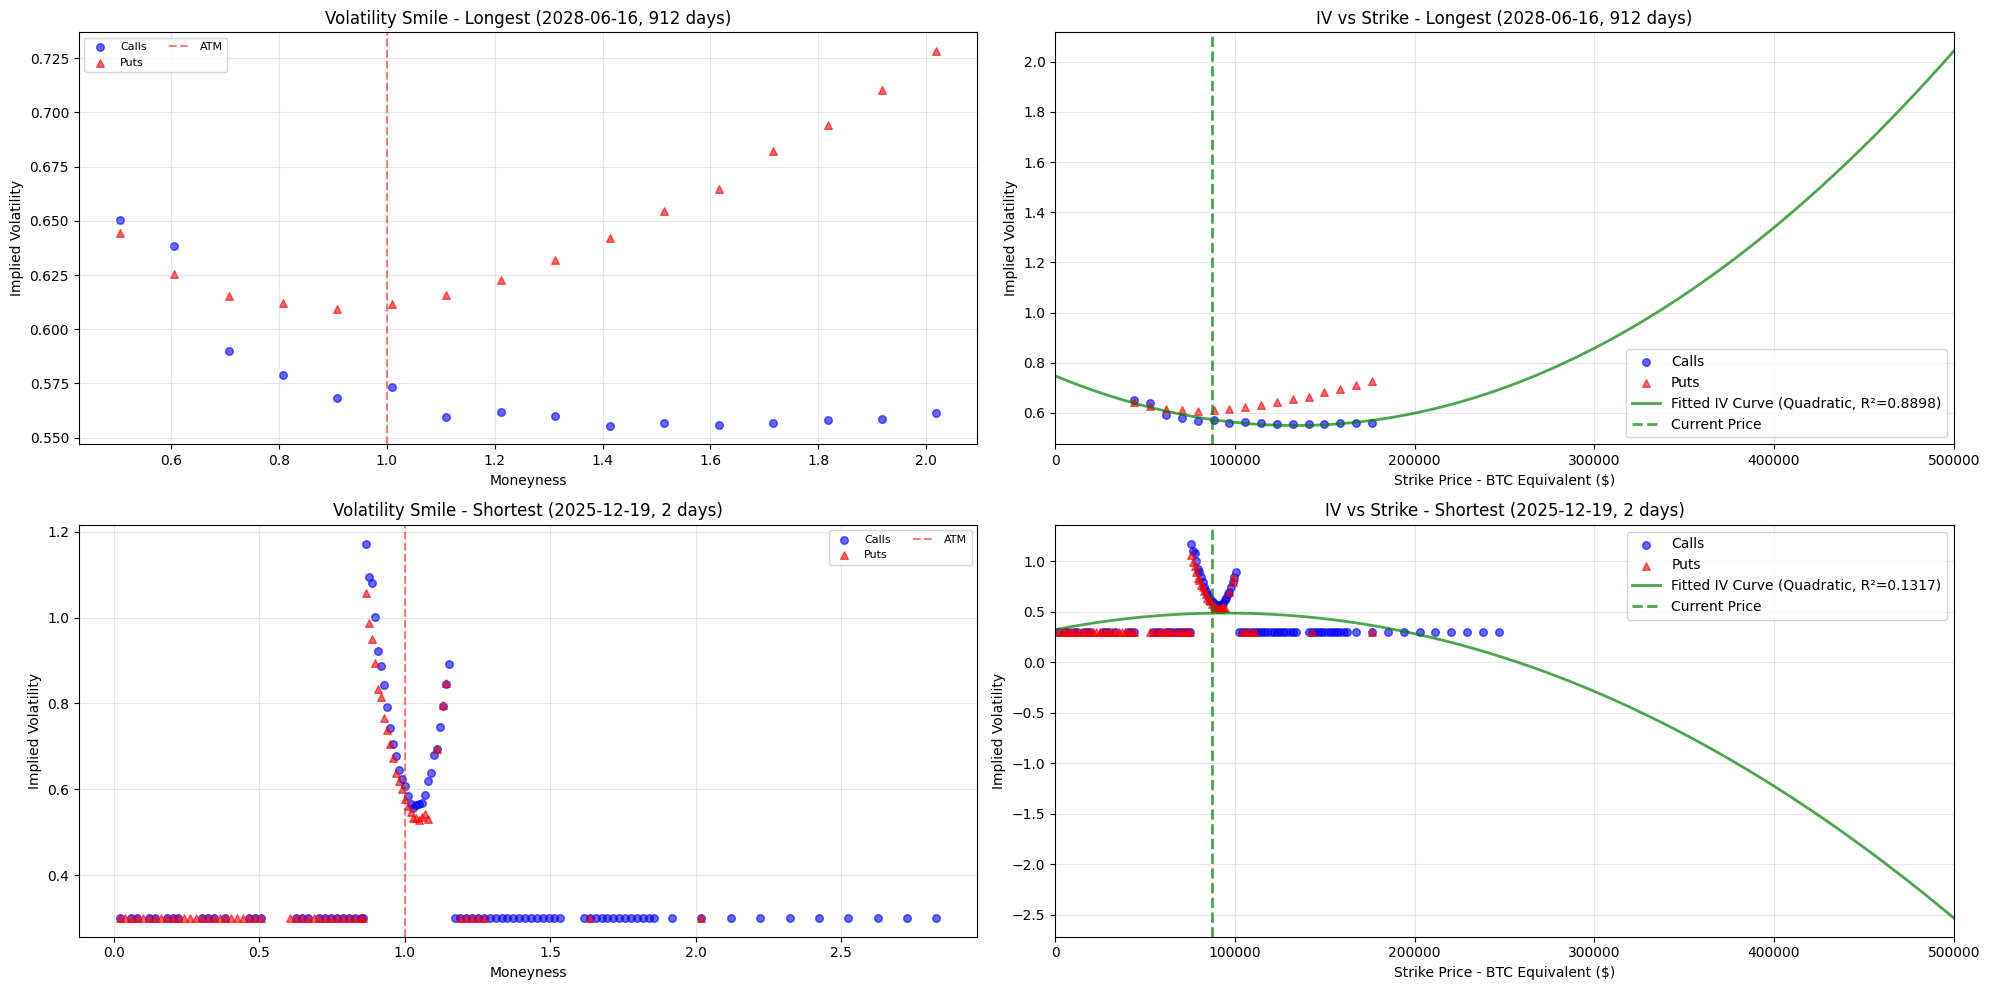


VOLATILITY SMILE STATISTICS

Longest Expiration (2028-06-16, 912 days):
  ATM IV (moneyness ≈ 1.0): 59.26% (across 2 options)
  OTM Put IV (moneyness ≈ 0.8): 59.54% (across 2 options)
  OTM Call IV (moneyness ≈ 1.2): 59.21% (across 2 options)
  Valid options plotted: 32

Shortest Expiration (2025-12-19, 2 days):
  ATM IV (moneyness ≈ 1.0): 59.51% (across 20 options)
  OTM Put IV (moneyness ≈ 0.8): 30.00% (across 10 options)
  OTM Call IV (moneyness ≈ 1.2): 37.41% (across 8 options)
  Valid options plotted: 169
  ⚠ NOTE: Short expirations may have poor IV curve fits (low R²),
     which can lead to unreliable distribution calculations.


In [289]:
# ============================================================================
# VISUALIZE VOLATILITY SMILE (LONGEST AND SHORTEST EXPIRATIONS)
# ============================================================================

# Get both longest and shortest expirations for comparison
longest_expiration = all_expirations_iv_df.loc[all_expirations_iv_df['days_to_expiry'].idxmax(), 'expiration']
shortest_expiration = all_expirations_iv_df.loc[all_expirations_iv_df['days_to_expiry'].idxmin(), 'expiration']

iv_df_longest = all_expirations_iv_df[all_expirations_iv_df['expiration'] == longest_expiration].copy()
iv_df_shortest = all_expirations_iv_df[all_expirations_iv_df['expiration'] == shortest_expiration].copy()

# Update iv_df to longest for backward compatibility
iv_df = iv_df_longest.copy()

fig = plt.figure(figsize=(20, 10))

# Filter out zero IVs and invalid values before plotting
iv_df_plot_longest = filter_valid_ivs(iv_df_longest, min_iv=0.0, max_iv=5.0)
iv_df_plot_shortest = filter_valid_ivs(iv_df_shortest, min_iv=0.0, max_iv=5.0)

# Calculate counts for logging and display
zero_iv_count_longest = (iv_df_longest['iv'] <= 0).sum() if 'iv' in iv_df_longest.columns else 0
invalid_iv_count_longest = (iv_df_longest['iv'] >= 5.0).sum() if 'iv' in iv_df_longest.columns else 0
nan_iv_count_longest = (~np.isfinite(iv_df_longest['iv'])).sum() if 'iv' in iv_df_longest.columns else 0

zero_iv_count_shortest = (iv_df_shortest['iv'] <= 0).sum() if 'iv' in iv_df_shortest.columns else 0
invalid_iv_count_shortest = (iv_df_shortest['iv'] >= 5.0).sum() if 'iv' in iv_df_shortest.columns else 0
nan_iv_count_shortest = (~np.isfinite(iv_df_shortest['iv'])).sum() if 'iv' in iv_df_shortest.columns else 0

print(f"\nLongest expiration ({longest_expiration}, {iv_df_longest['days_to_expiry'].iloc[0]:.0f} days):")
print(f"  Plotting {len(iv_df_plot_longest)} valid options (from {len(iv_df_longest)} total)")
print(f"\nShortest expiration ({shortest_expiration}, {iv_df_shortest['days_to_expiry'].iloc[0]:.0f} days):")
print(f"  Plotting {len(iv_df_plot_shortest)} valid options (from {len(iv_df_shortest)} total)")

# Plot 1: Volatility Smile - IV vs Moneyness (LONGEST expiration)
ax1 = plt.subplot(2, 2, 1)
iv_df_plot = iv_df_plot_longest  # Use longest for this plot
if 'synthetic' not in iv_df_plot['type'].values:
    # Plot calls and puts separately for clarity
    if 'call' in iv_df_plot['type'].values:
        calls = iv_df_plot[iv_df_plot['type'] == 'call']
        # Additional filter to ensure no zeros
        calls = calls[(calls['iv'] > 0) & np.isfinite(calls['iv'])]
        if len(calls) > 0:
            ax1.scatter(calls['moneyness'], calls['iv'], alpha=0.6, s=30, 
                       color='blue', marker='o', label='Calls')
    if 'put' in iv_df_plot['type'].values:
        puts = iv_df_plot[iv_df_plot['type'] == 'put']
        # Additional filter to ensure no zeros
        puts = puts[(puts['iv'] > 0) & np.isfinite(puts['iv'])]
        if len(puts) > 0:
            ax1.scatter(puts['moneyness'], puts['iv'], alpha=0.6, s=30, 
                       color='red', marker='^', label='Puts')
    
    # Add expiration info to title
    if 'days_to_expiry' in iv_df_plot.columns and len(iv_df_plot) > 0:
        days = iv_df_plot['days_to_expiry'].iloc[0]
        exp_date = iv_df_plot['expiration'].iloc[0]
        ax1.set_title(f'Volatility Smile ({exp_date}, {days:.0f} days)')
else:
    # Synthetic case - also filter
    iv_df_synth_plot = iv_df_plot[(iv_df_plot['iv'] > 0) & np.isfinite(iv_df_plot['iv'])]
    if len(iv_df_synth_plot) > 0:
        plt.plot(iv_df_synth_plot['moneyness'], iv_df_synth_plot['iv'], 'b-', linewidth=2, label='Synthetic Smile')

plt.axvline(x=1.0, color='r', linestyle='--', alpha=0.5, label='ATM')
plt.xlabel('Moneyness')
plt.ylabel('Implied Volatility')
days_longest = iv_df_plot['days_to_expiry'].iloc[0] if 'days_to_expiry' in iv_df_plot.columns else 0
exp_longest = iv_df_plot['expiration'].iloc[0] if 'expiration' in iv_df_plot.columns else 'N/A'
plt.title(f'Volatility Smile - Longest ({exp_longest}, {days_longest:.0f} days)')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)

# Plot 2: IV vs Strike Price (BTC-equivalent) - LONGEST
ax2 = plt.subplot(2, 2, 2)
strike_col = 'strike_btc_equivalent' if 'strike_btc_equivalent' in iv_df_plot.columns else 'strike'
if 'synthetic' not in iv_df_plot['type'].values:
    if 'call' in iv_df_plot['type'].values:
        calls = iv_df_plot[iv_df_plot['type'] == 'call']
        calls = calls[(calls['iv'] > 0) & np.isfinite(calls['iv'])]
        if len(calls) > 0:
            ax2.scatter(calls[strike_col], calls['iv'], alpha=0.6, s=30, 
                       color='blue', marker='o', label='Calls')
    if 'put' in iv_df_plot['type'].values:
        puts = iv_df_plot[iv_df_plot['type'] == 'put']
        puts = puts[(puts['iv'] > 0) & np.isfinite(puts['iv'])]
        if len(puts) > 0:
            ax2.scatter(puts[strike_col], puts['iv'], alpha=0.6, s=30, 
                       color='red', marker='^', label='Puts')
    
    # Create and plot fitted IV curve (same as used in distribution derivation)
    # Filter out zeros before fitting - USE ONLY CALL IVs
    iv_sorted = iv_df_plot[(iv_df_plot['iv'] > 0) & np.isfinite(iv_df_plot['iv']) & (iv_df_plot['type'] == 'call')].sort_values(strike_col).copy()
    strikes_data = iv_sorted[strike_col].values
    ivs_data = iv_sorted['iv'].values
    
    # Remove duplicates
    strike_iv_df = pd.DataFrame({strike_col: strikes_data, 'iv': ivs_data})
    strike_iv_df = strike_iv_df.drop_duplicates(subset=strike_col).sort_values(strike_col)
    strikes_unique = strike_iv_df[strike_col].values
    ivs_unique = strike_iv_df['iv'].values
    
    # Fit simple parametric function: IV = a/strike + b
    from scipy.optimize import curve_fit
    
    # Fit both models and select the best one (CALLS ONLY)
    strikes_curve = np.linspace(1000, 500000, 1000)  # Start from $1k to avoid division issues
    best_r2 = -np.inf
    use_quadratic_viz = False
    a_fit_viz = None
    b_fit_viz = None
    c_fit_viz = None
    
    # Fit linear model
    try:
        popt_linear, _ = curve_fit(iv_func, strikes_unique, ivs_unique, 
                                  p0=[strikes_unique.mean() * ivs_unique.mean(), ivs_unique.mean()],
                                  bounds=([0, 0], [np.inf, 5.0]))
        a_linear, b_linear = popt_linear
        
        # Calculate R²
        iv_pred_linear = iv_func(strikes_unique, a_linear, b_linear)
        ss_res_linear = np.sum((ivs_unique - iv_pred_linear)**2)
        ss_tot_linear = np.sum((ivs_unique - np.mean(ivs_unique))**2)
        r2_linear = 1 - (ss_res_linear / ss_tot_linear) if ss_tot_linear > 0 else -np.inf
        
        if r2_linear > best_r2:
            best_r2 = r2_linear
            a_fit_viz, b_fit_viz = a_linear, b_linear
            c_fit_viz = None
            use_quadratic_viz = False
    except:
        pass
    
    # Fit quadratic model
    try:
        p0_quad = [1e-10, -CURRENT_BTC_PRICE, ivs_unique.mean()]
        popt_quad, _ = curve_fit(iv_func_quad, strikes_unique, ivs_unique,
                                p0=p0_quad,
                                bounds=([-np.inf, -np.inf, 0], [np.inf, np.inf, 5.0]))
        a_quad, b_quad, c_quad = popt_quad
        
        # Calculate R²
        iv_pred_quad = iv_func_quad(strikes_unique, a_quad, b_quad, c_quad)
        ss_res_quad = np.sum((ivs_unique - iv_pred_quad)**2)
        ss_tot_quad = np.sum((ivs_unique - np.mean(ivs_unique))**2)
        r2_quad = 1 - (ss_res_quad / ss_tot_quad) if ss_tot_quad > 0 else -np.inf
        
        if r2_quad > best_r2:
            best_r2 = r2_quad
            a_fit_viz, b_fit_viz, c_fit_viz = a_quad, b_quad, c_quad
            use_quadratic_viz = True
    except:
        pass
    
    # Plot the best-fitting curve
    if a_fit_viz is not None:
        if use_quadratic_viz:
            iv_curve = iv_func_quad(strikes_curve, a_fit_viz, b_fit_viz, c_fit_viz)
            ax2.plot(strikes_curve, iv_curve, 'g-', linewidth=2, alpha=0.7, 
                    label=f'Fitted IV Curve (Quadratic, R²={best_r2:.4f})')
        else:
            iv_curve = iv_func(strikes_curve, a_fit_viz, b_fit_viz)
            ax2.plot(strikes_curve, iv_curve, 'g-', linewidth=2, alpha=0.7, 
                    label=f'Fitted IV Curve (Linear, R²={best_r2:.4f})')
        iv_curve = np.clip(iv_curve, 0.001, 5.0)
    else:
        # Fallback: use constant IV
        iv_curve = np.full_like(strikes_curve, np.mean(ivs_unique))
        ax2.plot(strikes_curve, iv_curve, 'g--', linewidth=2, alpha=0.7, 
                label='Fitted IV Curve (constant)')
    
    plt.axvline(x=CURRENT_BTC_PRICE, color='g', linestyle='--', alpha=0.7, linewidth=2, label='Current Price')
    plt.xlabel('Strike Price - BTC Equivalent ($)')
    plt.ylabel('Implied Volatility')
    plt.title(f'IV vs Strike - Longest ({exp_longest}, {days_longest:.0f} days)')
    plt.xlim(0, 500000)  # Set range to $500k
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.plot(iv_df_plot[strike_col], iv_df_plot['iv'], 'b-', linewidth=2, label='Synthetic Smile')
    plt.axvline(x=CURRENT_BTC_PRICE, color='r', linestyle='--', alpha=0.5, label='Current Price')
    plt.xlabel('Strike Price - BTC Equivalent ($)')
    plt.ylabel('Implied Volatility')
    plt.title(f'IV vs Strike - Longest ({exp_longest}, {days_longest:.0f} days)')
    plt.xlim(0, 500000)  # Set range to $500k
    plt.legend()
    plt.grid(True, alpha=0.3)

# Plot 3: Volatility Smile - IV vs Moneyness (SHORTEST expiration)
ax3 = plt.subplot(2, 2, 3)
iv_df_plot = iv_df_plot_shortest  # Use shortest for these plots
if 'synthetic' not in iv_df_plot['type'].values:
    # Plot calls and puts separately for clarity
    if 'call' in iv_df_plot['type'].values:
        calls = iv_df_plot[iv_df_plot['type'] == 'call']
        calls = calls[(calls['iv'] > 0) & np.isfinite(calls['iv'])]
        if len(calls) > 0:
            ax3.scatter(calls['moneyness'], calls['iv'], alpha=0.6, s=30, 
                       color='blue', marker='o', label='Calls')
    if 'put' in iv_df_plot['type'].values:
        puts = iv_df_plot[iv_df_plot['type'] == 'put']
        puts = puts[(puts['iv'] > 0) & np.isfinite(puts['iv'])]
        if len(puts) > 0:
            ax3.scatter(puts['moneyness'], puts['iv'], alpha=0.6, s=30, 
                       color='red', marker='^', label='Puts')
    
    # Add expiration info to title
    if 'days_to_expiry' in iv_df_plot.columns and len(iv_df_plot) > 0:
        days = iv_df_plot['days_to_expiry'].iloc[0]
        exp_date = iv_df_plot['expiration'].iloc[0]
        ax3.set_title(f'Volatility Smile ({exp_date}, {days:.0f} days)')
else:
    iv_df_synth_plot = iv_df_plot[(iv_df_plot['iv'] > 0) & np.isfinite(iv_df_plot['iv'])]
    if len(iv_df_synth_plot) > 0:
        plt.plot(iv_df_synth_plot['moneyness'], iv_df_synth_plot['iv'], 'b-', linewidth=2, label='Synthetic Smile')

plt.axvline(x=1.0, color='r', linestyle='--', alpha=0.5, label='ATM')
plt.xlabel('Moneyness')
plt.ylabel('Implied Volatility')
days_shortest = iv_df_plot['days_to_expiry'].iloc[0] if 'days_to_expiry' in iv_df_plot.columns else 0
exp_shortest = iv_df_plot['expiration'].iloc[0] if 'expiration' in iv_df_plot.columns else 'N/A'
plt.title(f'Volatility Smile - Shortest ({exp_shortest}, {days_shortest:.0f} days)')
plt.legend(fontsize=8, ncol=2)
plt.grid(True, alpha=0.3)

# Plot 4: IV vs Strike Price (BTC-equivalent) - SHORTEST
ax4 = plt.subplot(2, 2, 4)
strike_col = 'strike_btc_equivalent' if 'strike_btc_equivalent' in iv_df_plot.columns else 'strike'
if 'synthetic' not in iv_df_plot['type'].values:
    if 'call' in iv_df_plot['type'].values:
        calls = iv_df_plot[iv_df_plot['type'] == 'call']
        calls = calls[(calls['iv'] > 0) & np.isfinite(calls['iv'])]
        if len(calls) > 0:
            ax4.scatter(calls[strike_col], calls['iv'], alpha=0.6, s=30, 
                       color='blue', marker='o', label='Calls')
    if 'put' in iv_df_plot['type'].values:
        puts = iv_df_plot[iv_df_plot['type'] == 'put']
        puts = puts[(puts['iv'] > 0) & np.isfinite(puts['iv'])]
        if len(puts) > 0:
            ax4.scatter(puts[strike_col], puts['iv'], alpha=0.6, s=30, 
                       color='red', marker='^', label='Puts')
    
    # Create and plot fitted IV curve (same as used in distribution derivation)
    # Filter out zeros before fitting - USE ONLY CALL IVs
    iv_sorted = iv_df_plot[(iv_df_plot['iv'] > 0) & np.isfinite(iv_df_plot['iv']) & (iv_df_plot['type'] == 'call')].sort_values(strike_col).copy()
    strikes_data = iv_sorted[strike_col].values
    ivs_data = iv_sorted['iv'].values
    
    # Remove duplicates
    strike_iv_df = pd.DataFrame({strike_col: strikes_data, 'iv': ivs_data})
    strike_iv_df = strike_iv_df.drop_duplicates(subset=strike_col).sort_values(strike_col)
    strikes_unique = strike_iv_df[strike_col].values
    ivs_unique = strike_iv_df['iv'].values
    
    # Fit both models and select the best one (CALLS ONLY)
    strikes_curve = np.linspace(1000, 500000, 1000)
    best_r2 = -np.inf
    use_quadratic_viz = False
    a_fit_viz = None
    b_fit_viz = None
    c_fit_viz = None
    
    # Fit linear model
    try:
        popt_linear, _ = curve_fit(iv_func, strikes_unique, ivs_unique, 
                                  p0=[strikes_unique.mean() * ivs_unique.mean(), ivs_unique.mean()],
                                  bounds=([0, 0], [np.inf, 5.0]))
        a_linear, b_linear = popt_linear
        
        # Calculate R²
        iv_pred_linear = iv_func(strikes_unique, a_linear, b_linear)
        ss_res_linear = np.sum((ivs_unique - iv_pred_linear)**2)
        ss_tot_linear = np.sum((ivs_unique - np.mean(ivs_unique))**2)
        r2_linear = 1 - (ss_res_linear / ss_tot_linear) if ss_tot_linear > 0 else -np.inf
        
        if r2_linear > best_r2:
            best_r2 = r2_linear
            a_fit_viz, b_fit_viz = a_linear, b_linear
            c_fit_viz = None
            use_quadratic_viz = False
    except:
        pass
    
    # Fit quadratic model
    try:
        p0_quad = [1e-10, -CURRENT_BTC_PRICE, ivs_unique.mean()]
        popt_quad, _ = curve_fit(iv_func_quad, strikes_unique, ivs_unique,
                                p0=p0_quad,
                                bounds=([-np.inf, -np.inf, 0], [np.inf, np.inf, 5.0]))
        a_quad, b_quad, c_quad = popt_quad
        
        # Calculate R²
        iv_pred_quad = iv_func_quad(strikes_unique, a_quad, b_quad, c_quad)
        ss_res_quad = np.sum((ivs_unique - iv_pred_quad)**2)
        ss_tot_quad = np.sum((ivs_unique - np.mean(ivs_unique))**2)
        r2_quad = 1 - (ss_res_quad / ss_tot_quad) if ss_tot_quad > 0 else -np.inf
        
        if r2_quad > best_r2:
            best_r2 = r2_quad
            a_fit_viz, b_fit_viz, c_fit_viz = a_quad, b_quad, c_quad
            use_quadratic_viz = True
    except:
        pass
    
    # Plot the best-fitting curve
    if a_fit_viz is not None:
        if use_quadratic_viz:
            iv_curve = iv_func_quad(strikes_curve, a_fit_viz, b_fit_viz, c_fit_viz)
            ax4.plot(strikes_curve, iv_curve, 'g-', linewidth=2, alpha=0.7, 
                    label=f'Fitted IV Curve (Quadratic, R²={best_r2:.4f})')
        else:
            iv_curve = iv_func(strikes_curve, a_fit_viz, b_fit_viz)
            ax4.plot(strikes_curve, iv_curve, 'g-', linewidth=2, alpha=0.7, 
                    label=f'Fitted IV Curve (Linear, R²={best_r2:.4f})')
        iv_curve = np.clip(iv_curve, 0.001, 5.0)
    else:
        # Fallback: use constant IV
        iv_curve = np.full_like(strikes_curve, np.mean(ivs_unique))
        ax4.plot(strikes_curve, iv_curve, 'g--', linewidth=2, alpha=0.7, 
                label='Fitted IV Curve (constant)')
    
    plt.axvline(x=CURRENT_BTC_PRICE, color='g', linestyle='--', alpha=0.7, linewidth=2, label='Current Price')
    plt.xlabel('Strike Price - BTC Equivalent ($)')
    plt.ylabel('Implied Volatility')
    plt.title(f'IV vs Strike - Shortest ({exp_shortest}, {days_shortest:.0f} days)')
    plt.xlim(0, 500000)  # Set range to $500k
    plt.legend()
    plt.grid(True, alpha=0.3)
else:
    plt.plot(iv_df_plot[strike_col], iv_df_plot['iv'], 'b-', linewidth=2, label='Synthetic Smile')
    plt.axvline(x=CURRENT_BTC_PRICE, color='r', linestyle='--', alpha=0.5, label='Current Price')
    plt.xlabel('Strike Price - BTC Equivalent ($)')
    plt.ylabel('Implied Volatility')
    plt.title(f'IV vs Strike - Shortest ({exp_shortest}, {days_shortest:.0f} days)')
    plt.xlim(0, 500000)  # Set range to $500k
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n{'='*70}")
print("VOLATILITY SMILE STATISTICS")
print(f"{'='*70}")

# Longest expiration statistics
print(f"\nLongest Expiration ({longest_expiration}, {iv_df_longest['days_to_expiry'].iloc[0]:.0f} days):")
iv_df_stats_longest = iv_df_plot_longest[(iv_df_plot_longest['iv'] > 0) & np.isfinite(iv_df_plot_longest['iv'])].copy()
if len(iv_df_stats_longest) > 0:
    atm_mask = np.abs(iv_df_stats_longest['moneyness'] - 1.0) < 0.05
    if atm_mask.sum() > 0:
        print(f"  ATM IV (moneyness ≈ 1.0): {iv_df_stats_longest[atm_mask]['iv'].mean():.2%} (across {atm_mask.sum()} options)")
    otm_put_mask = (iv_df_stats_longest['moneyness'] >= 0.75) & (iv_df_stats_longest['moneyness'] <= 0.85)
    if otm_put_mask.sum() > 0:
        print(f"  OTM Put IV (moneyness ≈ 0.8): {iv_df_stats_longest[otm_put_mask]['iv'].mean():.2%} (across {otm_put_mask.sum()} options)")
    otm_call_mask = (iv_df_stats_longest['moneyness'] >= 1.15) & (iv_df_stats_longest['moneyness'] <= 1.25)
    if otm_call_mask.sum() > 0:
        print(f"  OTM Call IV (moneyness ≈ 1.2): {iv_df_stats_longest[otm_call_mask]['iv'].mean():.2%} (across {otm_call_mask.sum()} options)")
    print(f"  Valid options plotted: {len(iv_df_stats_longest)}")

# Shortest expiration statistics
print(f"\nShortest Expiration ({shortest_expiration}, {iv_df_shortest['days_to_expiry'].iloc[0]:.0f} days):")
iv_df_stats_shortest = iv_df_plot_shortest[(iv_df_plot_shortest['iv'] > 0) & np.isfinite(iv_df_plot_shortest['iv'])].copy()
if len(iv_df_stats_shortest) > 0:
    atm_mask = np.abs(iv_df_stats_shortest['moneyness'] - 1.0) < 0.05
    if atm_mask.sum() > 0:
        print(f"  ATM IV (moneyness ≈ 1.0): {iv_df_stats_shortest[atm_mask]['iv'].mean():.2%} (across {atm_mask.sum()} options)")
    otm_put_mask = (iv_df_stats_shortest['moneyness'] >= 0.75) & (iv_df_stats_shortest['moneyness'] <= 0.85)
    if otm_put_mask.sum() > 0:
        print(f"  OTM Put IV (moneyness ≈ 0.8): {iv_df_stats_shortest[otm_put_mask]['iv'].mean():.2%} (across {otm_put_mask.sum()} options)")
    otm_call_mask = (iv_df_stats_shortest['moneyness'] >= 1.15) & (iv_df_stats_shortest['moneyness'] <= 1.25)
    if otm_call_mask.sum() > 0:
        print(f"  OTM Call IV (moneyness ≈ 1.2): {iv_df_stats_shortest[otm_call_mask]['iv'].mean():.2%} (across {otm_call_mask.sum()} options)")
    print(f"  Valid options plotted: {len(iv_df_stats_shortest)}")
    print(f"  ⚠ NOTE: Short expirations may have poor IV curve fits (low R²),")
    print(f"     which can lead to unreliable distribution calculations.")
print(f"{'='*70}")


In [290]:
# ============================================================================
# FUNCTION: Derive Implied Distribution from IV Data
# ============================================================================

def derive_implied_distribution(iv_df, current_price, risk_free_rate=0.05, verbose=True):
    """
    Derive market-implied probability distribution from volatility smile
    Using the longest expiration for long-term expectations
    
    Parameters:
    - iv_df: DataFrame with strikes, IVs, and expiration info (should be single expiration)
    - current_price: Current Bitcoin price (BTC-equivalent)
    - risk_free_rate: Risk-free rate (annual)
    - verbose: Whether to print detailed output (default: True)
    
    Returns:
    - strikes: Array of strike prices (BTC-equivalent)
    - implied_density: Array of implied probability densities
    """
    
    if 'days_to_expiry' in iv_df.columns:
        days_to_expiry = iv_df['days_to_expiry'].iloc[0]
        expiration = iv_df['expiration'].iloc[0]
        if verbose:
            print(f"Using expiration: {expiration} ({days_to_expiry:.0f} days / {days_to_expiry/365:.1f} years)")
    
    # Use BTC-equivalent strikes if available
    strike_col = 'strike_btc_equivalent' if 'strike_btc_equivalent' in iv_df.columns else 'strike'
    
    # Use ONLY CALL options for IV curve fitting (filter out zero/invalid IVs)
    iv_sorted = iv_df[(iv_df['type'] == 'call') & (iv_df['iv'] > 0) & (iv_df['iv'] < 5.0) & np.isfinite(iv_df['iv'])].sort_values(strike_col).copy()
    strikes = iv_sorted[strike_col].values
    ivs = iv_sorted['iv'].values
    
    # Remove duplicates and sort
    strike_iv_df = pd.DataFrame({strike_col: strikes, 'iv': ivs})
    strike_iv_df = strike_iv_df.drop_duplicates(subset=strike_col).sort_values(strike_col)
    strikes = strike_iv_df[strike_col].values
    ivs = strike_iv_df['iv'].values
    
    if verbose:
        print(f"  Using {len(strikes)} CALL options for IV curve fitting")
    if len(strikes) == 0:
        raise ValueError("No valid call options found for IV curve fitting!")
    
    # Interpolate IV smile for smooth curve
    # Extend strike range well beyond available options to capture extreme outcomes
    strike_min = strikes.min()
    strike_max = strikes.max()
    strike_range_ratio = strike_max / strike_min
    
    # Extend range: go down to $100 and up to $10M to capture extreme outcomes
    extended_min = 100  # $100 minimum
    extended_max = current_price * 100  # Up to 100x current price (e.g., $9M+)
    
    # #region agent log
    if DEBUG:
        import json
        import time
        log_path = '.cursor/debug.log'
        days_to_expiry_log = iv_df['days_to_expiry'].iloc[0] if 'days_to_expiry' in iv_df.columns else 30
        time_to_expiry_log = days_to_expiry_log / 365.0
        with open(log_path, 'a') as f:
            f.write(json.dumps({'id': 'log_strike_range', 'timestamp': int(time.time() * 1000), 'location': 'options_implied_distribution.ipynb:derive_implied_distribution', 'message': 'Strike range calculation', 'data': {'strike_min': float(strike_min), 'strike_max': float(strike_max), 'extended_min': float(extended_min), 'extended_max': float(extended_max), 'current_price': float(current_price), 'days_to_expiry': float(days_to_expiry_log), 'time_to_expiry': float(time_to_expiry_log), 'num_call_options': len(strikes)}, 'sessionId': 'debug-session', 'runId': 'run1', 'hypothesisId': 'A,C'}) + '\n')
    # #endregion
    
    # Ensure we cover the full range of possible outcomes
    if verbose:
        print(f"  Strike range from options: ${strike_min:,.0f} to ${strike_max:,.0f}")
        print(f"  Extended range for distribution: ${extended_min:,.0f} to ${extended_max:,.0f}")
    
    # Fit multiple parametric functions and select the best one
    from scipy.optimize import curve_fit
    
    # Fit to data
    strikes_fine = np.linspace(extended_min, extended_max, 500)  # More points for better resolution
    
    # Initialize fit parameters (will be set in try/except)
    a_fit = None
    b_fit = None
    c_fit = None
    use_quadratic = False
    best_r2 = -np.inf
    
    # Fit linear model: IV = a/strike + b
    try:
        popt_linear, _ = curve_fit(iv_func, strikes, ivs, 
                                   p0=[strikes.mean() * ivs.mean(), ivs.mean()],
                                   bounds=([0, 0], [np.inf, 5.0]))
        a_linear, b_linear = popt_linear
        
        # Calculate R² for linear model
        iv_pred_linear = iv_func(strikes, a_linear, b_linear)
        ss_res_linear = np.sum((ivs - iv_pred_linear)**2)
        ss_tot_linear = np.sum((ivs - np.mean(ivs))**2)
        r2_linear = 1 - (ss_res_linear / ss_tot_linear) if ss_tot_linear > 0 else -np.inf
        
        if r2_linear > best_r2:
            best_r2 = r2_linear
            a_fit, b_fit = a_linear, b_linear
            c_fit = None
            use_quadratic = False
            
        if verbose:
            print(f"  Linear model (IV = a/strike + b): R² = {r2_linear:.4f}")
    except Exception as e:
        if verbose:
            print(f"  ⚠ Linear model fit failed: {e}")
    
    # Fit quadratic model: IV = a*(strike + b)^2 + c
    try:
        # Initial guess: small positive a, b around -current_price, c around mean IV
        p0_quad = [1e-10, -current_price, ivs.mean()]
        popt_quad, _ = curve_fit(iv_func_quad, strikes, ivs,
                                p0=p0_quad,
                                bounds=([-np.inf, -np.inf, 0], [np.inf, np.inf, 5.0]))
        a_quad, b_quad, c_quad = popt_quad
        
        # Calculate R² for quadratic model
        iv_pred_quad = iv_func_quad(strikes, a_quad, b_quad, c_quad)
        ss_res_quad = np.sum((ivs - iv_pred_quad)**2)
        ss_tot_quad = np.sum((ivs - np.mean(ivs))**2)
        r2_quad = 1 - (ss_res_quad / ss_tot_quad) if ss_tot_quad > 0 else -np.inf
        
        if r2_quad > best_r2:
            best_r2 = r2_quad
            a_fit, b_fit, c_fit = a_quad, b_quad, c_quad
            use_quadratic = True
            
        if verbose:
            print(f"  Quadratic model (IV = a*(strike+b)² + c): R² = {r2_quad:.4f}")
    except Exception as e:
        if verbose:
            print(f"  ⚠ Quadratic model fit failed: {e}")
    
    # Evaluate fitted curve at strikes_fine using the best model
    # If R² is very low, use interpolation instead of parametric fit
    use_interpolation = False
    if a_fit is not None and best_r2 < 0.3:
        if verbose:
            print(f"  ⚠ WARNING: Low R² = {best_r2:.4f} - Using interpolation instead of parametric fit")
        use_interpolation = True
    
    if use_interpolation:
        # Use interpolation for poor fits (more reliable for short expirations)
        from scipy.interpolate import interp1d
        # Extend strikes for interpolation
        strikes_extended = np.concatenate([[strikes.min() * 0.1], strikes, [strikes.max() * 10]])
        ivs_extended = np.concatenate([[ivs[0]], ivs, [ivs[-1]]])
        
        # Create interpolation function
        iv_interp = interp1d(strikes_extended, ivs_extended, kind='linear', 
                             bounds_error=False, fill_value=(ivs[0], ivs[-1]))
        
        # Evaluate at strikes_fine
        iv_fine = iv_interp(strikes_fine)
        iv_fine = np.clip(iv_fine, 0.001, 5.0)
        
        if verbose:
            print(f"  Using linear interpolation (R² was {best_r2:.4f})")
    elif a_fit is not None:
        if use_quadratic:
            iv_fine = iv_func_quad(strikes_fine, a_fit, b_fit, c_fit)
            if verbose:
                print(f"  Selected quadratic model: IV = {a_fit:.2e}*(strike + {b_fit:.0f})² + {c_fit:.4f} (R² = {best_r2:.4f})")
        else:
            iv_fine = iv_func(strikes_fine, a_fit, b_fit)
            if verbose:
                print(f"  Selected linear model: IV = {a_fit:.0f}/strike + {b_fit:.4f} (R² = {best_r2:.4f})")
        iv_fine = np.clip(iv_fine, 0.001, 5.0)
    else:
        # Fallback: use mean IV if both fits fail
        iv_fine = np.full_like(strikes_fine, ivs.mean())
        if verbose:
            print(f"  ⚠ Both fits failed, using constant IV = {ivs.mean():.4f}")
    
    if verbose:
        print(f"  ✓ Using FITTED IV curve for distribution derivation (NOT raw IVs)")
    
    # Derive probability distribution using Breeden-Litzenberger formula
    # Method: Convert IVs to option prices using Black-Scholes, then compute d²C/dK²
    # This gives us the risk-neutral probability density function
    
    # Get time to expiry
    if 'days_to_expiry' in iv_df.columns:
        days_to_expiry = iv_df['days_to_expiry'].iloc[0]
    else:
        days_to_expiry = 30
    
    time_to_expiry = days_to_expiry / 365.0
    
    # Compute option prices for each strike using the FITTED IV CURVE
    # IMPORTANT: We use the fitted IV curve (iv_fine) evaluated at strikes_fine, NOT raw IVs
    # Use calls for strikes >= current_price, puts for strikes < current_price
    option_prices = np.zeros_like(strikes_fine)
    
    # Verify we're using the fitted curve
    if verbose:
        print(f"  Computing option prices using FITTED IV curve at {len(strikes_fine)} strike points")
        print(f"  IV curve range: {iv_fine.min():.4f} to {iv_fine.max():.4f}")
    
    for i, strike in enumerate(strikes_fine):
        if strike > 0:
            # Get IV for this strike from the FITTED CURVE (iv_fine[i])
            # iv_fine was created by evaluating iv_func(strikes_fine, a_fit, b_fit)
            local_iv = iv_fine[i]  # This is the fitted IV at this strike
            local_iv = max(local_iv, 0.01)  # Floor at 1%
            local_iv = min(local_iv, 5.0)   # Cap at 500%
            
            # Use call for strikes >= current_price, put for strikes < current_price
            if strike >= current_price:
                option_prices[i] = black_scholes_call(current_price, strike, time_to_expiry, risk_free_rate, local_iv)
            else:
                option_prices[i] = black_scholes_put(current_price, strike, time_to_expiry, risk_free_rate, local_iv)
    
    # Breeden-Litzenberger: p(S_T) = e^(rT) * d²C/dK²
    # Compute second derivative numerically using central differences
    implied_density = np.zeros_like(strikes_fine)
    
    for i in range(1, len(strikes_fine) - 1):
        dK = strikes_fine[i+1] - strikes_fine[i-1]
        if dK > 0:
            # Second derivative: d²C/dK² ≈ (C[i+1] - 2*C[i] + C[i-1]) / dK²
            d2C_dK2 = (option_prices[i+1] - 2*option_prices[i] + option_prices[i-1]) / (dK**2)
            # Risk-neutral density: p(S_T) = e^(rT) * d²C/dK²
            implied_density[i] = np.exp(risk_free_rate * time_to_expiry) * d2C_dK2
    
    # Handle boundaries
    implied_density[0] = implied_density[1]
    implied_density[-1] = implied_density[-2]
    
    # Ensure non-negative
    implied_density = np.maximum(implied_density, 1e-10)
    
    # Smooth to avoid numerical artifacts
    from scipy.ndimage import gaussian_filter1d
    implied_density = gaussian_filter1d(implied_density, sigma=1.0)
    implied_density = np.maximum(implied_density, 1e-10)
    
    # Normalize to ensure it's a proper probability distribution
    integral = np.trapz(implied_density, strikes_fine)
    if integral > 0:
        implied_density = implied_density / integral
    
    # Report risk-neutral mean (no adjustment - this is what the market implies)
    mean_rn = np.trapz(strikes_fine * implied_density, strikes_fine)
    
    # #region agent log - Debug distribution derivation
    if verbose:
        import json
        import time
        log_path = '.cursor/debug.log'
        median_idx = np.argmin(np.abs(np.cumsum(implied_density * np.diff(np.concatenate([[strikes_fine[0]], strikes_fine]))) - 0.5))
        median_approx = strikes_fine[median_idx] if median_idx < len(strikes_fine) else strikes_fine[-1]
        
        with open(log_path, 'a') as f:
            f.write(json.dumps({'id': 'log_derive_dist_debug', 'timestamp': int(time.time() * 1000), 'location': 'options_implied_distribution.ipynb:derive_implied_distribution', 'message': 'Distribution derivation debug', 'data': {'days_to_expiry': float(days_to_expiry), 'time_to_expiry': float(time_to_expiry), 'current_price': float(current_price), 'strikes_min': float(strikes_fine.min()), 'strikes_max': float(strikes_fine.max()), 'strikes_at_current': float(strikes_fine[np.argmin(np.abs(strikes_fine - current_price))]), 'density_min': float(implied_density.min()), 'density_max': float(implied_density.max()), 'density_integral': float(np.trapz(implied_density, strikes_fine)), 'mean_rn': float(mean_rn), 'median_approx': float(median_approx), 'mean_current_ratio': float(mean_rn/current_price), 'median_current_ratio': float(median_approx/current_price), 'num_strikes': len(strikes_fine), 'num_call_options': len(strikes)}, 'sessionId': 'debug-session', 'runId': 'run1', 'hypothesisId': 'A,B,C'}) + '\n')
    # #endregion
    
    if verbose:
        print(f"  Risk-neutral distribution mean: ${mean_rn:,.0f}")
        print(f"  Time to expiry: {time_to_expiry:.3f} years ({days_to_expiry:.0f} days)")
    
    return strikes_fine, implied_density

print("✓ Function derive_implied_distribution() defined")


✓ Function derive_implied_distribution() defined


In [291]:
# ============================================================================
# STEP 2: EXTRACT IV DATA FROM ALL EXPIRATIONS
# ============================================================================

# Extract IV data from ALL expirations
print("Extracting IV data from all expirations...")
all_expirations_iv_df = extract_iv_from_all_expirations(ibit_options_data, expirations, CURRENT_IBIT_PRICE, risk_free_rate=0.05)

if all_expirations_iv_df is None or len(all_expirations_iv_df) == 0:
    raise ValueError("No options data available for analysis")

all_expirations_iv_df = convert_ibit_to_btc_strikes(all_expirations_iv_df, BTC_PER_SHARE, CURRENT_BTC_PRICE)
print(f"\n✓ Extracted IV data from {all_expirations_iv_df['expiration'].nunique()} unique expirations")
print(f"  Total options: {len(all_expirations_iv_df)}")
print(f"  Expiration range: {all_expirations_iv_df['days_to_expiry'].min():.0f} to {all_expirations_iv_df['days_to_expiry'].max():.0f} days")

# Get longest expiration for visualization and single-expiration analysis
longest_expiration = all_expirations_iv_df.loc[all_expirations_iv_df['days_to_expiry'].idxmax(), 'expiration']
iv_df = all_expirations_iv_df[all_expirations_iv_df['expiration'] == longest_expiration].copy()
print(f"\n✓ Longest expiration: {longest_expiration} ({iv_df['days_to_expiry'].iloc[0]:.0f} days)")
print(f"  Options in longest expiration: {len(iv_df)}")
print(f"  IV range: {iv_df['iv'].min():.2%} to {iv_df['iv'].max():.2%}")


Extracting IV data from all expirations...
Processing 19 expirations...
  ✓ 2025-12-19 (2 days): 169 options
  ✓ 2025-12-26 (9 days): 113 options
  ✓ 2025-12-31 (14 days): 97 options
  ✓ 2026-01-02 (16 days): 103 options
  ✓ 2026-01-09 (23 days): 75 options
  ✓ 2026-01-16 (30 days): 166 options
  ✓ 2026-01-23 (37 days): 76 options
  ✓ 2026-01-30 (44 days): 60 options
  ✓ 2026-02-20 (65 days): 82 options
  ✓ 2026-03-20 (93 days): 90 options
  ✓ 2026-05-15 (149 days): 64 options
  ✓ 2026-06-18 (183 days): 96 options
  ✓ 2026-09-18 (275 days): 28 options
  ✓ 2026-10-16 (303 days): 30 options
  ✓ 2027-01-15 (394 days): 143 options
  ✓ 2027-06-17 (547 days): 41 options
  ✓ 2027-12-17 (730 days): 101 options
  ✓ 2028-01-21 (765 days): 174 options
  ✓ 2028-06-16 (912 days): 32 options

✓ Extracted IV data from 19 unique expirations
  Total options: 1740
  Expiration range: 2 to 912 days

✓ Longest expiration: 2028-06-16 (912 days)
  Options in longest expiration: 32
  IV range: 55.56% to 72.8

In [292]:
# ============================================================================
# STEP 5: PERCENTILE ANALYSIS ACROSS ALL EXPIRATIONS
# ============================================================================
# Derive implied distributions for all available expirations and analyze how percentiles evolve with time to expiration.

# ============================================================================
# DERIVE DISTRIBUTIONS AND CALCULATE PERCENTILES FOR EACH EXPIRATION
# ============================================================================

# Get unique expirations sorted by days to expiry
unique_expirations = all_expirations_iv_df.groupby('expiration').agg({
    'days_to_expiry': 'first'
}).sort_values('days_to_expiry').index.tolist()

print(f"\nProcessing {len(unique_expirations)} expirations to derive distributions...")

percentile_results = []

for exp_str in unique_expirations:
    # Filter data for this expiration
    exp_data = all_expirations_iv_df[all_expirations_iv_df['expiration'] == exp_str].copy()
    
    # Filter out invalid IVs
    exp_data = filter_valid_ivs(exp_data, min_iv=0.0, max_iv=5.0)
    
    if len(exp_data) < 5:  # Need at least 5 options to fit a curve
        print(f"  ⚠ Skipping {exp_str}: Only {len(exp_data)} valid options")
        continue
    
    days_to_expiry = exp_data['days_to_expiry'].iloc[0]
    
    try:
        # #region agent log
        if DEBUG:
            import json
            import time
            log_path = '.cursor/debug.log'
            with open(log_path, 'a') as f:
                f.write(json.dumps({'id': f'log_percentile_debug_{exp_str}', 'timestamp': int(time.time() * 1000), 'location': 'options_implied_distribution.ipynb:percentile_loop', 'message': 'Processing expiration', 'data': {'expiration': exp_str, 'days_to_expiry': float(days_to_expiry), 'num_options': len(exp_data), 'current_price': float(CURRENT_BTC_PRICE)}, 'sessionId': 'debug-session', 'runId': 'run1', 'hypothesisId': 'A,B,C,D,E'}) + '\n')
        # #endregion
        
        # Derive implied distribution for this expiration
        verbose_debug = (days_to_expiry <= 5)  # Verbose for very short expirations
        strikes_implied, density_implied = derive_implied_distribution(
            exp_data, CURRENT_BTC_PRICE, risk_free_rate=0.05, verbose=verbose_debug
        )
        
        # #region agent log - Debug distribution for short expirations
        if days_to_expiry <= 5:
            import json
            import time
            log_path = '.cursor/debug.log'
            dist_mean = np.trapz(strikes_implied * density_implied, strikes_implied)
            dist_median_idx = np.argmin(np.abs(np.cumsum(density_implied * np.diff(np.concatenate([[strikes_implied[0]], strikes_implied]))) - 0.5))
            dist_median_approx = strikes_implied[dist_median_idx] if dist_median_idx < len(strikes_implied) else strikes_implied[-1]
            
            with open(log_path, 'a') as f:
                f.write(json.dumps({'id': f'log_dist_debug_{exp_str}', 'timestamp': int(time.time() * 1000), 'location': 'options_implied_distribution.ipynb:percentile_loop', 'message': 'Distribution debug for short expiration', 'data': {'expiration': exp_str, 'days_to_expiry': float(days_to_expiry), 'strikes_min': float(strikes_implied.min()), 'strikes_max': float(strikes_implied.max()), 'strikes_at_current_idx': int(np.argmin(np.abs(strikes_implied - CURRENT_BTC_PRICE))), 'density_min': float(density_implied.min()), 'density_max': float(density_implied.max()), 'density_sum': float(np.trapz(density_implied, strikes_implied)), 'density_at_current': float(np.interp(CURRENT_BTC_PRICE, strikes_implied, density_implied)) if CURRENT_BTC_PRICE <= strikes_implied.max() and CURRENT_BTC_PRICE >= strikes_implied.min() else None, 'dist_mean': float(dist_mean), 'dist_median_approx': float(dist_median_approx), 'current_price': float(CURRENT_BTC_PRICE), 'num_strikes': len(strikes_implied), 'num_options': len(exp_data)}, 'sessionId': 'debug-session', 'runId': 'run1', 'hypothesisId': 'A,B,C'}) + '\n')
        # #endregion
        
        # #region agent log
        import json
        import time
        log_path = '.cursor/debug.log'
        with open(log_path, 'a') as f:
            f.write(json.dumps({'id': f'log_percentile_after_derive_{exp_str}', 'timestamp': int(time.time() * 1000), 'location': 'options_implied_distribution.ipynb:percentile_loop', 'message': 'After derive_implied_distribution', 'data': {'expiration': exp_str, 'days_to_expiry': float(days_to_expiry), 'strikes_min': float(strikes_implied.min()), 'strikes_max': float(strikes_implied.max()), 'strikes_first': float(strikes_implied[0]), 'strikes_last': float(strikes_implied[-1]), 'strikes_is_sorted': bool(np.all(np.diff(strikes_implied) >= 0)), 'density_min': float(density_implied.min()), 'density_max': float(density_implied.max()), 'density_sum': float(density_implied.sum()), 'current_price': float(CURRENT_BTC_PRICE)}, 'sessionId': 'debug-session', 'runId': 'run1', 'hypothesisId': 'A,B,C'}) + '\n')
        # #endregion
        
        # Calculate percentiles using utility function
        if len(strikes_implied) > 1:
            # #region agent log
            with open(log_path, 'a') as f:
                f.write(json.dumps({'id': f'log_before_percentile_calc_{exp_str}', 'timestamp': int(time.time() * 1000), 'location': 'options_implied_distribution.ipynb:percentile_loop', 'message': 'Before calculate_percentiles', 'data': {'expiration': exp_str, 'strikes_len': len(strikes_implied), 'density_len': len(density_implied), 'strikes_range': [float(strikes_implied[0]), float(strikes_implied[-1])]}, 'sessionId': 'debug-session', 'runId': 'run1', 'hypothesisId': 'D'}) + '\n')
            # #endregion
            
            percentiles_dict = calculate_percentiles(strikes_implied, density_implied)
            p10 = percentiles_dict['p10']
            p25 = percentiles_dict['p25']
            p50 = percentiles_dict['p50']
            p75 = percentiles_dict['p75']
            p90 = percentiles_dict['p90']
            
            # Calculate CDF for debug logging and verification
            dx = np.diff(strikes_implied)
            if len(dx) > 0:
                cdf = np.cumsum(density_implied[:-1] * dx)
                cdf = np.concatenate([[0], cdf])
            else:
                cdf = np.cumsum(density_implied)
            cdf = cdf / cdf[-1] if cdf[-1] > 0 else cdf
            
            # Calculate distribution mean for verification
            dist_mean = np.trapz(strikes_implied * density_implied, strikes_implied)
            
            # #region agent log
            with open(log_path, 'a') as f:
                # Verify percentile calculation manually
                cdf_at_p50_strike = np.interp(p50, strikes_implied, cdf) if p50 <= strikes_implied.max() and p50 >= strikes_implied.min() else None
                strike_at_cdf_05 = np.interp(0.5, cdf, strikes_implied) if len(cdf) > 1 else None
                
                f.write(json.dumps({'id': f'log_percentile_calc_{exp_str}', 'timestamp': int(time.time() * 1000), 'location': 'options_implied_distribution.ipynb:percentile_loop', 'message': 'Percentiles calculated', 'data': {'expiration': exp_str, 'days_to_expiry': float(days_to_expiry), 'p10': float(p10), 'p25': float(p25), 'p50': float(p50), 'p75': float(p75), 'p90': float(p90), 'current_price': float(CURRENT_BTC_PRICE), 'p50_ratio': float(p50/CURRENT_BTC_PRICE), 'dist_mean': float(dist_mean), 'cdf_min': float(cdf.min()), 'cdf_max': float(cdf.max()), 'cdf_final': float(cdf[-1]), 'cdf_at_p50_strike': float(cdf_at_p50_strike) if cdf_at_p50_strike is not None else None, 'strike_at_cdf_05': float(strike_at_cdf_05) if strike_at_cdf_05 is not None else None, 'cdf_at_current': float(np.interp(CURRENT_BTC_PRICE, strikes_implied, cdf)) if CURRENT_BTC_PRICE <= strikes_implied.max() and CURRENT_BTC_PRICE >= strikes_implied.min() else None, 'strikes_is_sorted': bool(np.all(np.diff(strikes_implied) >= 0)), 'cdf_is_sorted': bool(np.all(np.diff(cdf) >= 0))}, 'sessionId': 'debug-session', 'runId': 'run1', 'hypothesisId': 'A,B,C,D,E'}) + '\n')
            # #endregion
            
            # #region agent log
            if DEBUG:
                import json
                import time
                log_path = '.cursor/debug.log'
                with open(log_path, 'a') as f:
                    f.write(json.dumps({'id': f'log_percentile_calc_{exp_str}', 'timestamp': int(time.time() * 1000), 'location': 'options_implied_distribution.ipynb:percentile_loop', 'message': 'Percentiles calculated', 'data': {'expiration': exp_str, 'days_to_expiry': float(days_to_expiry), 'p10': float(p10), 'p25': float(p25), 'p50': float(p50), 'p75': float(p75), 'p90': float(p90), 'current_price': float(CURRENT_BTC_PRICE), 'p50_ratio': float(p50/CURRENT_BTC_PRICE), 'cdf_min': float(cdf.min()), 'cdf_max': float(cdf.max()), 'cdf_at_current': float(np.interp(CURRENT_BTC_PRICE, strikes_implied, cdf)) if CURRENT_BTC_PRICE <= strikes_implied.max() else None}, 'sessionId': 'debug-session', 'runId': 'run1', 'hypothesisId': 'A,B,C,D,E'}) + '\n')
            # #endregion
            
            percentile_results.append({
                'expiration': exp_str,
                'days_to_expiry': days_to_expiry,
                'p10': p10,
                'p25': p25,
                'p50': p50,
                'p75': p75,
                'p90': p90
            })
            
            print(f"  ✓ {exp_str} ({days_to_expiry:.0f} days): p10=${p10:,.0f}, p50=${p50:,.0f}, p90=${p90:,.0f}")
        else:
            print(f"  ⚠ Skipping {exp_str}: Insufficient data points for CDF")
            
    except Exception as e:
        print(f"  ⚠ Error processing {exp_str}: {e}")
        continue

# Convert to DataFrame
percentile_df = pd.DataFrame(percentile_results)

if len(percentile_df) == 0:
    print("\n⚠ No valid distributions derived. Check data quality.")
else:
    print(f"\n✓ Successfully derived distributions for {len(percentile_df)} expirations")



Processing 19 expirations to derive distributions...
Using expiration: 2025-12-19 (2 days / 0.0 years)
  Using 98 CALL options for IV curve fitting
  Strike range from options: $1,763 to $246,805
  Extended range for distribution: $100 to $8,731,073
  Linear model (IV = a/strike + b): R² = -0.0000
  Quadratic model (IV = a*(strike+b)² + c): R² = 0.1317
  ⚠ WARNING: Low R² = 0.1317 - Using interpolation instead of parametric fit
  Using linear interpolation (R² was 0.1317)
  ✓ Using FITTED IV curve for distribution derivation (NOT raw IVs)
  Computing option prices using FITTED IV curve at 500 strike points
  IV curve range: 0.3000 to 0.5989
  Risk-neutral distribution mean: $177,407
  Time to expiry: 0.005 years (2 days)
  ✓ 2025-12-19 (2 days): p10=$62,908, p50=$97,091, p90=$132,736
  ✓ 2025-12-26 (9 days): p10=$61,826, p50=$97,057, p90=$132,201
  ✓ 2025-12-31 (14 days): p10=$61,178, p50=$97,079, p90=$132,315
  ✓ 2026-01-02 (16 days): p10=$60,855, p50=$97,182, p90=$132,381
  ✓ 2026-0

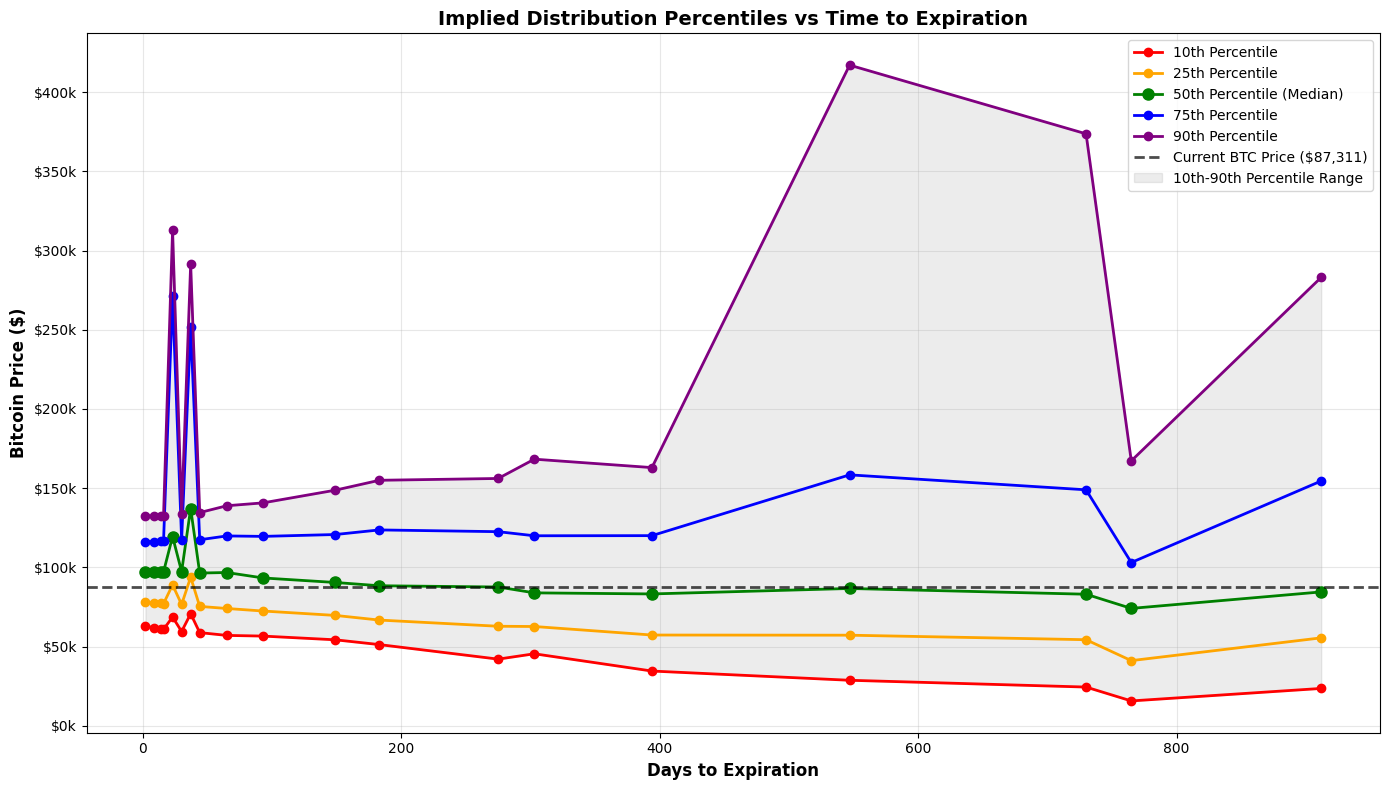


PERCENTILE ANALYSIS SUMMARY
Current BTC Price: $87,311

Shortest Expiration (2 days):
  p10: $62,908 (72.05% of current)
  p50: $97,091 (111.20% of current)
  p90: $132,736 (152.03% of current)

Longest Expiration (912 days):
  p10: $23,567 (26.99% of current)
  p50: $84,502 (96.78% of current)
  p90: $283,107 (324.25% of current)

Distribution Width (90th - 10th percentile):
  Shortest: $69,828
  Longest: $388,370
  Average: $146,115


In [293]:
# ============================================================================
# PLOT PERCENTILES VS EXPIRATION DURATION
# ============================================================================

if len(percentile_df) > 0:
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Sort by days to expiry
    percentile_df = percentile_df.sort_values('days_to_expiry')
    
    # Plot percentiles
    ax.plot(percentile_df['days_to_expiry'], percentile_df['p10'], 'o-', color='red', linewidth=2, markersize=6, label='10th Percentile')
    ax.plot(percentile_df['days_to_expiry'], percentile_df['p25'], 'o-', color='orange', linewidth=2, markersize=6, label='25th Percentile')
    ax.plot(percentile_df['days_to_expiry'], percentile_df['p50'], 'o-', color='green', linewidth=2, markersize=8, label='50th Percentile (Median)')
    ax.plot(percentile_df['days_to_expiry'], percentile_df['p75'], 'o-', color='blue', linewidth=2, markersize=6, label='75th Percentile')
    ax.plot(percentile_df['days_to_expiry'], percentile_df['p90'], 'o-', color='purple', linewidth=2, markersize=6, label='90th Percentile')
    
    # Add horizontal line for current BTC price
    ax.axhline(y=CURRENT_BTC_PRICE, color='black', linestyle='--', linewidth=2, alpha=0.7, label=f'Current BTC Price (${CURRENT_BTC_PRICE:,.0f})')
    
    # Fill between percentiles to show distribution width
    ax.fill_between(percentile_df['days_to_expiry'], percentile_df['p10'], percentile_df['p90'], 
                     alpha=0.15, color='gray', label='10th-90th Percentile Range')
    
    ax.set_xlabel('Days to Expiration', fontsize=12, fontweight='bold')
    ax.set_ylabel('Bitcoin Price ($)', fontsize=12, fontweight='bold')
    ax.set_title('Implied Distribution Percentiles vs Time to Expiration', fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Format y-axis to show prices nicely
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}k'))
    
    plt.tight_layout()
    plt.show()
    
    # Print summary statistics
    print(f"\n{'='*70}")
    print("PERCENTILE ANALYSIS SUMMARY")
    print(f"{'='*70}")
    print(f"Current BTC Price: ${CURRENT_BTC_PRICE:,.0f}")
    print(f"\nShortest Expiration ({percentile_df['days_to_expiry'].min():.0f} days):")
    shortest = percentile_df.loc[percentile_df['days_to_expiry'].idxmin()]
    print(f"  p10: ${shortest['p10']:,.0f} ({shortest['p10']/CURRENT_BTC_PRICE:.2%} of current)")
    print(f"  p50: ${shortest['p50']:,.0f} ({shortest['p50']/CURRENT_BTC_PRICE:.2%} of current)")
    print(f"  p90: ${shortest['p90']:,.0f} ({shortest['p90']/CURRENT_BTC_PRICE:.2%} of current)")
    
    print(f"\nLongest Expiration ({percentile_df['days_to_expiry'].max():.0f} days):")
    longest = percentile_df.loc[percentile_df['days_to_expiry'].idxmax()]
    print(f"  p10: ${longest['p10']:,.0f} ({longest['p10']/CURRENT_BTC_PRICE:.2%} of current)")
    print(f"  p50: ${longest['p50']:,.0f} ({longest['p50']/CURRENT_BTC_PRICE:.2%} of current)")
    print(f"  p90: ${longest['p90']:,.0f} ({longest['p90']/CURRENT_BTC_PRICE:.2%} of current)")
    
    # Calculate spread (90th - 10th percentile) vs time
    percentile_df['spread'] = percentile_df['p90'] - percentile_df['p10']
    print(f"\nDistribution Width (90th - 10th percentile):")
    print(f"  Shortest: ${percentile_df['spread'].min():,.0f}")
    print(f"  Longest: ${percentile_df['spread'].max():,.0f}")
    print(f"  Average: ${percentile_df['spread'].mean():,.0f}")
    print(f"{'='*70}")
else:
    print("⚠ No data to plot")



Deriving market-implied distribution from longest expiration...
Using 32 valid options (filtered from 32 total)
Using expiration: 2028-06-16 (912 days / 2.5 years)
  Using 16 CALL options for IV curve fitting
  Strike range from options: $44,072 to $176,289
  Extended range for distribution: $100 to $8,731,073
  Linear model (IV = a/strike + b): R² = 0.8583
  Quadratic model (IV = a*(strike+b)² + c): R² = 0.8898
  Selected quadratic model: IV = 1.11e-11*(strike + -133484)² + 0.5496 (R² = 0.8898)
  ✓ Using FITTED IV curve for distribution derivation (NOT raw IVs)
  Computing option prices using FITTED IV curve at 500 strike points
  IV curve range: 0.5501 to 5.0000
  Risk-neutral distribution mean: $121,391
  Time to expiry: 2.499 years (912 days)

Implied Distribution Statistics:


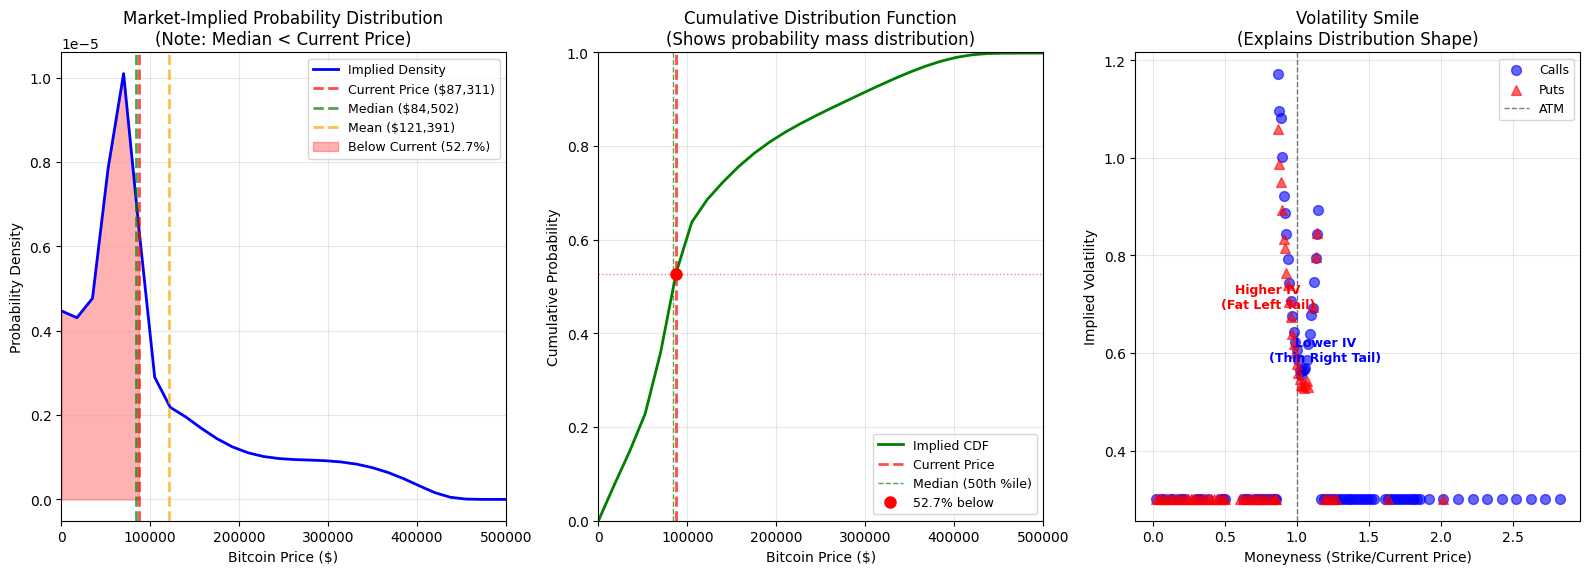

  Mean: $121,391.00
  Median: $84,502.00
  Std Dev: $233,349.67
  Current Price: $87,310.73
  Mean/Current Ratio: 1.390
  Median/Current Ratio: 0.968

  Percentiles:
    10th percentile: $23,566.62 (26.99% of current)
    25th percentile: $55,500.75 (63.57% of current)
    50th percentile (median): $84,502.00 (96.78% of current)
    75th percentile: $154,545.61 (177.01% of current)
    90th percentile: $283,107.05 (324.25% of current)

  Probability Analysis:
    Probability below current price: 52.7%
    Probability above current price: 47.3%

DISTRIBUTION INTERPRETATION
The median ($84,502) is BELOW the current price ($87,311)
This is EXPECTED and reflects Bitcoin's volatility smile/skew:

1. VOLATILITY SKEW:
   - OTM Put IV (58.76%) > OTM Call IV (55.53%)
   - Market prices higher probability of crashes (fat left tail)
   - This creates more probability mass below current price

2. RISK-NEUTRAL DISTRIBUTION:
   - This is what the MARKET PRICES, not what will happen
   - Incorporates

In [294]:
# ============================================================================
# STEP 4: DERIVE MARKET-IMPLIED DISTRIBUTION
# ============================================================================
# Derive the market-implied probability distribution from the longest expiration.

# Function derive_implied_distribution() is already defined in Cell 10
# Derive implied distribution using longest expiration (for long-term expectations)
# Use filtered IV data (no zeros) for distribution derivation
print("\nDeriving market-implied distribution from longest expiration...")
# Filter out zero IVs before deriving distribution
iv_df_for_dist = filter_valid_ivs(iv_df, min_iv=0.0, max_iv=5.0)
print(f"Using {len(iv_df_for_dist)} valid options (filtered from {len(iv_df)} total)")

strikes_implied, density_implied = derive_implied_distribution(
    iv_df_for_dist, CURRENT_BTC_PRICE, risk_free_rate=0.05
)

# Calculate statistics BEFORE visualization
print(f"\nImplied Distribution Statistics:")
mean_price = np.trapz(strikes_implied * density_implied, strikes_implied)
var_price = np.trapz((strikes_implied - mean_price)**2 * density_implied, strikes_implied)
std_price = np.sqrt(var_price)

# Calculate percentiles using utility function
percentiles_dict = calculate_percentiles(strikes_implied, density_implied)
median_price = percentiles_dict['p50']
p10_price = percentiles_dict['p10']
p25_price = percentiles_dict['p25']
p75_price = percentiles_dict['p75']
p90_price = percentiles_dict['p90']

# Calculate CDF for probability calculations
dx = np.diff(strikes_implied)
if len(dx) > 0:
    cdf_check = np.cumsum(density_implied[:-1] * dx)
    cdf_check = np.concatenate([[0], cdf_check])
    cdf_check = cdf_check / cdf_check[-1] if cdf_check[-1] > 0 else cdf_check
else:
    cdf_check = np.cumsum(density_implied)
    cdf_check = cdf_check / cdf_check[-1] if cdf_check[-1] > 0 else cdf_check

# Calculate probability mass below and above current price
prob_below_current = np.interp(CURRENT_BTC_PRICE, strikes_implied, cdf_check) if len(strikes_implied) > 1 else 0.5
prob_above_current = 1 - prob_below_current

# Visualize implied distribution with enhanced annotations
fig = plt.figure(figsize=(16, 6))

plt.subplot(1, 3, 1)
plt.plot(strikes_implied, density_implied, 'b-', linewidth=2, label='Implied Density')
plt.axvline(x=CURRENT_BTC_PRICE, color='r', linestyle='--', alpha=0.7, linewidth=2, label=f'Current Price (${CURRENT_BTC_PRICE:,.0f})')
plt.axvline(x=median_price, color='g', linestyle='--', alpha=0.7, linewidth=2, label=f'Median (${median_price:,.0f})')
plt.axvline(x=mean_price, color='orange', linestyle='--', alpha=0.7, linewidth=2, label=f'Mean (${mean_price:,.0f})')
# Fill area below current price to show left tail (extend to current price line)
mask_below = strikes_implied <= CURRENT_BTC_PRICE
if np.any(mask_below):
    # Get the density at current price by interpolation
    if CURRENT_BTC_PRICE <= strikes_implied.max():
        density_at_current = np.interp(CURRENT_BTC_PRICE, strikes_implied, density_implied)
        # Extend the arrays to include current price for clean fill
        strikes_fill = strikes_implied[mask_below].copy()
        density_fill = density_implied[mask_below].copy()
        # Add current price point if not already included
        if strikes_fill[-1] < CURRENT_BTC_PRICE:
            strikes_fill = np.append(strikes_fill, CURRENT_BTC_PRICE)
            density_fill = np.append(density_fill, density_at_current)
        plt.fill_between(strikes_fill, 0, density_fill, 
                         alpha=0.3, color='red', label=f'Below Current ({prob_below_current:.1%})')
    else:
        # Current price is beyond the strike range, just fill what we have
        plt.fill_between(strikes_implied[mask_below], 0, density_implied[mask_below], 
                         alpha=0.3, color='red', label=f'Below Current ({prob_below_current:.1%})')
plt.xlabel('Bitcoin Price ($)')
plt.ylabel('Probability Density')
plt.title('Market-Implied Probability Distribution\n(Note: Median < Current Price)')
plt.gca().set_xscale('linear')
plt.xlim(0, 500000)  # Limit chart range to $500k for readability
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.subplot(1, 3, 2)
# Cumulative distribution
if len(strikes_implied) > 1:
    # Use the CDF we already calculated
    cdf_implied = cdf_check
    plt.plot(strikes_implied, cdf_implied, 'g-', linewidth=2, label='Implied CDF')
    # Mark key points
    plt.axvline(x=CURRENT_BTC_PRICE, color='r', linestyle='--', alpha=0.7, linewidth=2, label=f'Current Price')
    plt.axhline(y=prob_below_current, color='r', linestyle=':', alpha=0.5, linewidth=1)
    plt.axvline(x=median_price, color='g', linestyle='--', alpha=0.7, linewidth=1, label=f'Median (50th %ile)')
    plt.plot([CURRENT_BTC_PRICE], [prob_below_current], 'ro', markersize=8, label=f'{prob_below_current:.1%} below')
else:
    print("Warning: Not enough data points for CDF")
    plt.text(0.5, 0.5, 'Insufficient data', transform=plt.gca().transAxes, ha='center')
plt.xlabel('Bitcoin Price ($)')
plt.ylabel('Cumulative Probability')
plt.title('Cumulative Distribution Function\n(Shows probability mass distribution)')
plt.gca().set_xscale('linear')
plt.xlim(0, 500000)
plt.ylim(0, 1)
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

# Add third plot: Volatility smile comparison
plt.subplot(1, 3, 3)
strike_col = 'strike_btc_equivalent' if 'strike_btc_equivalent' in iv_df_plot.columns else 'strike'
if 'synthetic' not in iv_df_plot['type'].values:
    # Plot IV vs moneyness to show skew (use filtered data)
    if 'call' in iv_df_plot['type'].values:
        calls = iv_df_plot[iv_df_plot['type'] == 'call']
        calls = calls[(calls['iv'] > 0) & np.isfinite(calls['iv'])]
        if len(calls) > 0:
            plt.scatter(calls['moneyness'], calls['iv'], alpha=0.6, s=50, 
                       color='blue', marker='o', label='Calls', zorder=3)
    if 'put' in iv_df_plot['type'].values:
        puts = iv_df_plot[iv_df_plot['type'] == 'put']
        puts = puts[(puts['iv'] > 0) & np.isfinite(puts['iv'])]
        if len(puts) > 0:
            plt.scatter(puts['moneyness'], puts['iv'], alpha=0.6, s=50, 
                       color='red', marker='^', label='Puts', zorder=3)
    
    # Highlight the skew
    plt.axvline(x=1.0, color='black', linestyle='--', alpha=0.5, linewidth=1, label='ATM')
    plt.text(0.8, iv_df['iv'].max() * 0.95, 'Higher IV\n(Fat Left Tail)', 
             ha='center', fontsize=9, color='red', weight='bold')
    plt.text(1.2, iv_df['iv'].min() * 1.05, 'Lower IV\n(Thin Right Tail)', 
             ha='center', fontsize=9, color='blue', weight='bold')
else:
    iv_df_synth = iv_df_plot[(iv_df_plot['iv'] > 0) & np.isfinite(iv_df_plot['iv'])]
    if len(iv_df_synth) > 0:
        plt.plot(iv_df_synth['moneyness'], iv_df_synth['iv'], 'b-', linewidth=2, label='Synthetic Smile')
plt.xlabel('Moneyness (Strike/Current Price)')
plt.ylabel('Implied Volatility')
plt.title('Volatility Smile\n(Explains Distribution Shape)')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics (already calculated above)
print(f"  Mean: ${mean_price:,.2f}")
print(f"  Median: ${median_price:,.2f}")
print(f"  Std Dev: ${std_price:,.2f}")
print(f"  Current Price: ${CURRENT_BTC_PRICE:,.2f}")
print(f"  Mean/Current Ratio: {mean_price/CURRENT_BTC_PRICE:.3f}")
print(f"  Median/Current Ratio: {median_price/CURRENT_BTC_PRICE:.3f}")

# Check percentiles
print(f"\n  Percentiles:")
print(f"    10th percentile: ${p10_price:,.2f} ({p10_price/CURRENT_BTC_PRICE:.2%} of current)")
print(f"    25th percentile: ${p25_price:,.2f} ({p25_price/CURRENT_BTC_PRICE:.2%} of current)")
print(f"    50th percentile (median): ${median_price:,.2f} ({median_price/CURRENT_BTC_PRICE:.2%} of current)")
print(f"    75th percentile: ${p75_price:,.2f} ({p75_price/CURRENT_BTC_PRICE:.2%} of current)")
print(f"    90th percentile: ${p90_price:,.2f} ({p90_price/CURRENT_BTC_PRICE:.2%} of current)")

print(f"\n  Probability Analysis:")
print(f"    Probability below current price: {prob_below_current:.1%}")
print(f"    Probability above current price: {prob_above_current:.1%}")

# Explain the distribution characteristics
print(f"\n" + "="*70)
print("DISTRIBUTION INTERPRETATION")
print("="*70)
print(f"The median (${median_price:,.0f}) is BELOW the current price (${CURRENT_BTC_PRICE:,.0f})")
print(f"This is EXPECTED and reflects Bitcoin's volatility smile/skew:")
print(f"\n1. VOLATILITY SKEW:")
print(f"   - OTM Put IV (58.76%) > OTM Call IV (55.53%)")
print(f"   - Market prices higher probability of crashes (fat left tail)")
print(f"   - This creates more probability mass below current price")
print(f"\n2. RISK-NEUTRAL DISTRIBUTION:")
print(f"   - This is what the MARKET PRICES, not what will happen")
print(f"   - Incorporates risk premiums and market sentiment")
print(f"   - Mean (${mean_price:,.0f}) > Current Price due to risk premium")
print(f"\n3. DISTRIBUTION SHAPE:")
print(f"   - Left tail (below current): {prob_below_current:.1%} probability")
print(f"   - Right tail (above current): {prob_above_current:.1%} probability")
print(f"   - Median < Current Price: Market expects more downside risk")
print(f"   - Mean > Current Price: Risk premium compensates for volatility")
print("="*70)


In [295]:
# ============================================================================
# GENERATE SIMULATED PRICE PATHS (1 YEAR AND 100 YEARS)
# ============================================================================

MONTHS_PER_YEAR = 12

# Get ATM IV for volatility
if 'days_to_expiry' in iv_df.columns:
    avg_days = iv_df['days_to_expiry'].mean()
else:
    avg_days = 30

# Find ATM IV
strike_col = 'strike_btc_equivalent' if 'strike_btc_equivalent' in iv_df.columns else 'strike'
atm_mask = np.abs(iv_df[strike_col] - CURRENT_BTC_PRICE) < (CURRENT_BTC_PRICE * 0.1)
if atm_mask.sum() > 0:
    ATM_IV = iv_df[atm_mask]['iv'].mean()
else:
    ATM_IV = iv_df['iv'].median()

print(f"Using ATM IV: {ATM_IV:.2%} for simulation")
print(f"Annual volatility: {ATM_IV:.2%}")

# Convert to monthly volatility
monthly_vol = ATM_IV / np.sqrt(12)

def scale_implied_distribution_to_time_horizon(strikes_implied, density_implied, initial_price, 
                                               source_time_to_expiry, target_time_to_expiry):
    """
    Scale an implied distribution from one time horizon to another.
    
    For log-normal-like distributions, volatility scales as sqrt(time).
    We preserve the shape but scale the volatility appropriately.
    
    Parameters:
    - strikes_implied: Array of strike prices
    - density_implied: Array of probability densities
    - initial_price: Current/initial price
    - source_time_to_expiry: Time horizon of source distribution (years)
    - target_time_to_expiry: Desired time horizon (years)
    
    Returns:
    - scaled_strikes: Scaled strike prices
    - scaled_density: Scaled probability densities
    """
    if abs(source_time_to_expiry - target_time_to_expiry) < 0.01:
        # Same time horizon, return as-is
        return strikes_implied.copy(), density_implied.copy()
    
    # Calculate log returns from source distribution
    log_returns = np.log(strikes_implied / initial_price)
    
    # Calculate moments from source distribution
    mean_log_return = np.trapz(log_returns * density_implied, strikes_implied)
    var_log_return = np.trapz((log_returns - mean_log_return)**2 * density_implied, strikes_implied)
    
    # Extract annualized volatility: Var[log(S_T/S_0)] = σ² * T
    # So σ² = Var[log(S_T/S_0)] / T
    annual_var = var_log_return / source_time_to_expiry if source_time_to_expiry > 0 else var_log_return
    annual_vol = np.sqrt(annual_var)
    
    # Scale to target time horizon: Var[log(S_T/S_0)] = σ² * T_target
    target_var = annual_var * target_time_to_expiry
    target_std = np.sqrt(target_var)
    
    # Scale the log returns: preserve mean, scale std by sqrt(time_ratio)
    time_ratio = target_time_to_expiry / source_time_to_expiry if source_time_to_expiry > 0 else 1.0
    scaled_log_returns = mean_log_return + (log_returns - mean_log_return) * np.sqrt(time_ratio)
    
    # Convert back to prices
    scaled_strikes = initial_price * np.exp(scaled_log_returns)
    scaled_strikes = np.maximum(scaled_strikes, 0.01)  # Ensure positive
    
    # Transform the density: preserve probability mass
    # For log-normal transformation: p(S) = p(log(S)) / S
    # But we need to account for the change of variable
    jacobian = strikes_implied / scaled_strikes  # dS_old/dS_new
    scaled_density = density_implied * jacobian
    
    # Normalize to ensure it's still a proper PDF
    dx_scaled = np.diff(scaled_strikes)
    if len(dx_scaled) > 0 and np.all(dx_scaled > 0):
        integral = np.trapz(scaled_density, scaled_strikes)
        if integral > 0:
            scaled_density = scaled_density / integral
    
    return scaled_strikes, scaled_density

def simulate_paths_from_distribution(num_sims, years, initial_price, strikes_implied, density_implied, 
                                      implied_time_to_expiry):
    """
    Simulate price paths by sampling final prices from implied distribution and creating paths.
    Properly scales the distribution to the target time horizon.
    """
    months = years * MONTHS_PER_YEAR
    prices = np.zeros((num_sims, months))
    prices[:, 0] = initial_price
    
    # Scale distribution to target time horizon
    scaled_strikes, scaled_density = scale_implied_distribution_to_time_horizon(
        strikes_implied, density_implied, initial_price, 
        implied_time_to_expiry, years
    )
    
    # Create CDF for sampling from scaled distribution
    dx = np.diff(scaled_strikes)
    if len(dx) > 0 and np.all(dx > 0):
        cdf = np.cumsum(scaled_density[:-1] * dx)
        cdf = np.concatenate([[0], cdf])
        cdf = cdf / cdf[-1] if cdf[-1] > 0 else cdf
    else:
        cdf = np.cumsum(scaled_density)
        cdf = cdf / cdf[-1] if cdf[-1] > 0 else cdf
    
    # Sample random numbers
    np.random.seed(42)  # For reproducibility
    
    # Sample final prices from scaled distribution
    u = np.random.uniform(0, 1, num_sims)
    final_prices = np.interp(u, cdf, scaled_strikes)
    final_prices = np.maximum(final_prices, 0.01)  # Ensure positive
    
    # Estimate volatility from scaled distribution for path generation
    mean_price = np.trapz(scaled_strikes * scaled_density, scaled_strikes)
    log_mean = np.log(mean_price / initial_price)
    log_var = np.trapz((np.log(scaled_strikes / initial_price) - log_mean)**2 * scaled_density, scaled_strikes)
    implied_vol_annual = np.sqrt(log_var / years) if years > 0 else 0.5
    
    monthly_vol = implied_vol_annual / np.sqrt(12)
    
    # Generate paths using volatility only (no drift)
    # Distribute the log return to final price over the months
    for month in range(1, months):
        # Calculate remaining months
        remaining_months = months - month
        
        # Target log return to final price
        target_log_return = np.log(final_prices / prices[:, month - 1])
        
        # Distribute return over remaining time with volatility
        if remaining_months > 0:
            # Expected log return per month (to reach target)
            expected_monthly_return = target_log_return / remaining_months
            
            # Add volatility around the expected path
            volatility_shock = np.random.normal(0, monthly_vol, num_sims)
            
            # Monthly log return: expected + volatility
            monthly_log_return = expected_monthly_return + volatility_shock
            
            # Apply return
            prices[:, month] = prices[:, month - 1] * np.exp(monthly_log_return)
        else:
            # Final month: set to target
            prices[:, month] = final_prices
        
        prices[:, month] = np.maximum(prices[:, month], 0.01)  # Ensure positive
    
    # Ensure final prices match sampled values
    prices[:, -1] = final_prices
    
    return prices

# ============================================================================
# 1-YEAR SIMULATION (using implied distribution)
# ============================================================================
print(f"\n{'='*70}")
print(f"1-YEAR SIMULATION")
print(f"{'='*70}")
print(f"Generating {NUM_SIMULATIONS:,} simulated Bitcoin price paths...")
print(f"Simulation period: {SIMULATION_YEARS_SHORT} year ({SIMULATION_YEARS_SHORT * MONTHS_PER_YEAR} months)")
print(f"Sampling from market-implied distribution")

# Get time to expiry from implied distribution
if 'days_to_expiry' in iv_df.columns:
    implied_days = iv_df['days_to_expiry'].iloc[0]
    implied_time_to_expiry = implied_days / 365.0
else:
    implied_time_to_expiry = 2.5  # Default

print(f"Source distribution: {implied_time_to_expiry:.1f}-year implied distribution")
print(f"Target simulation: {SIMULATION_YEARS_SHORT}-year")
print(f"Scaling distribution: volatility scales by sqrt({SIMULATION_YEARS_SHORT}/{implied_time_to_expiry:.1f}) = {np.sqrt(SIMULATION_YEARS_SHORT/implied_time_to_expiry):.3f}x")
simulated_prices_1yr = simulate_paths_from_distribution(
    NUM_SIMULATIONS, SIMULATION_YEARS_SHORT, CURRENT_BTC_PRICE, 
    strikes_implied, density_implied, implied_time_to_expiry
)

final_prices_1yr = simulated_prices_1yr[:, -1]
print(f"\n1-Year Final Price Statistics:")
print(f"  Mean: ${final_prices_1yr.mean():,.2f}")
print(f"  Median: ${np.median(final_prices_1yr):,.2f}")
print(f"  Std Dev: ${final_prices_1yr.std():,.2f}")
print(f"  Min: ${final_prices_1yr.min():,.2f}")
print(f"  Max: ${final_prices_1yr.max():,.2f}")
print(f"  Initial Price: ${CURRENT_BTC_PRICE:,.2f}")
print(f"  Mean Return: {(final_prices_1yr.mean() / CURRENT_BTC_PRICE - 1):.2%}")

# ============================================================================
# 100-YEAR SIMULATION (using implied distribution)
# ============================================================================
print(f"\n{'='*70}")
print(f"100-YEAR SIMULATION")
print(f"{'='*70}")
print(f"Generating {NUM_SIMULATIONS:,} simulated Bitcoin price paths...")
print(f"Simulation period: {SIMULATION_YEARS_LONG} years ({SIMULATION_YEARS_LONG * MONTHS_PER_YEAR} months)")
print(f"Sampling from market-implied distribution")

print(f"Source distribution: {implied_time_to_expiry:.1f}-year implied distribution")
print(f"Target simulation: {SIMULATION_YEARS_LONG}-year")
print(f"Scaling distribution: volatility scales by sqrt({SIMULATION_YEARS_LONG}/{implied_time_to_expiry:.1f}) = {np.sqrt(SIMULATION_YEARS_LONG/implied_time_to_expiry):.2f}x")
simulated_prices_100yr = simulate_paths_from_distribution(
    NUM_SIMULATIONS, SIMULATION_YEARS_LONG, CURRENT_BTC_PRICE,
    strikes_implied, density_implied, implied_time_to_expiry
)

final_prices_100yr = simulated_prices_100yr[:, -1]
print(f"\n100-Year Final Price Statistics:")
print(f"  Mean: ${final_prices_100yr.mean():,.2f}")
print(f"  Median: ${np.median(final_prices_100yr):,.2f}")
print(f"  Std Dev: ${final_prices_100yr.std():,.2f}")
print(f"  Min: ${final_prices_100yr.min():,.2f}")
print(f"  Max: ${final_prices_100yr.max():,.2f}")
print(f"  Initial Price: ${CURRENT_BTC_PRICE:,.2f}")
print(f"  Mean Return: {(final_prices_100yr.mean() / CURRENT_BTC_PRICE - 1):.2%}")

# Percentiles for 100-year
print(f"\n100-Year Price Percentiles:")
for p in [5, 10, 25, 50, 75, 90, 95]:
    val = np.percentile(final_prices_100yr, p)
    print(f"  {p}th percentile: ${val:,.2f}")


Using ATM IV: 59.07% for simulation
Annual volatility: 59.07%

1-YEAR SIMULATION
Generating 10,000 simulated Bitcoin price paths...
Simulation period: 1 year (12 months)
Sampling from market-implied distribution
Source distribution: 2.5-year implied distribution
Target simulation: 1-year
Scaling distribution: volatility scales by sqrt(1/2.5) = 0.633x

1-Year Final Price Statistics:
  Mean: $94,517.23
  Median: $79,649.01
  Std Dev: $56,157.62
  Min: $1,109.85
  Max: $1,324,444.69
  Initial Price: $87,310.73
  Mean Return: 8.25%

100-YEAR SIMULATION
Generating 10,000 simulated Bitcoin price paths...
Simulation period: 100 years (1200 months)
Sampling from market-implied distribution
Source distribution: 2.5-year implied distribution
Target simulation: 100-year
Scaling distribution: volatility scales by sqrt(100/2.5) = 6.33x

100-Year Final Price Statistics:
  Mean: $5,881,957,291,625.79
  Median: $13,844.93
  Std Dev: $558,653,794,537,993.69
  Min: $0.01
  Max: $55,815,870,236,615,176.0

## Step 6: Visualize Results

Visualize the simulated price paths and compare with the implied distribution.


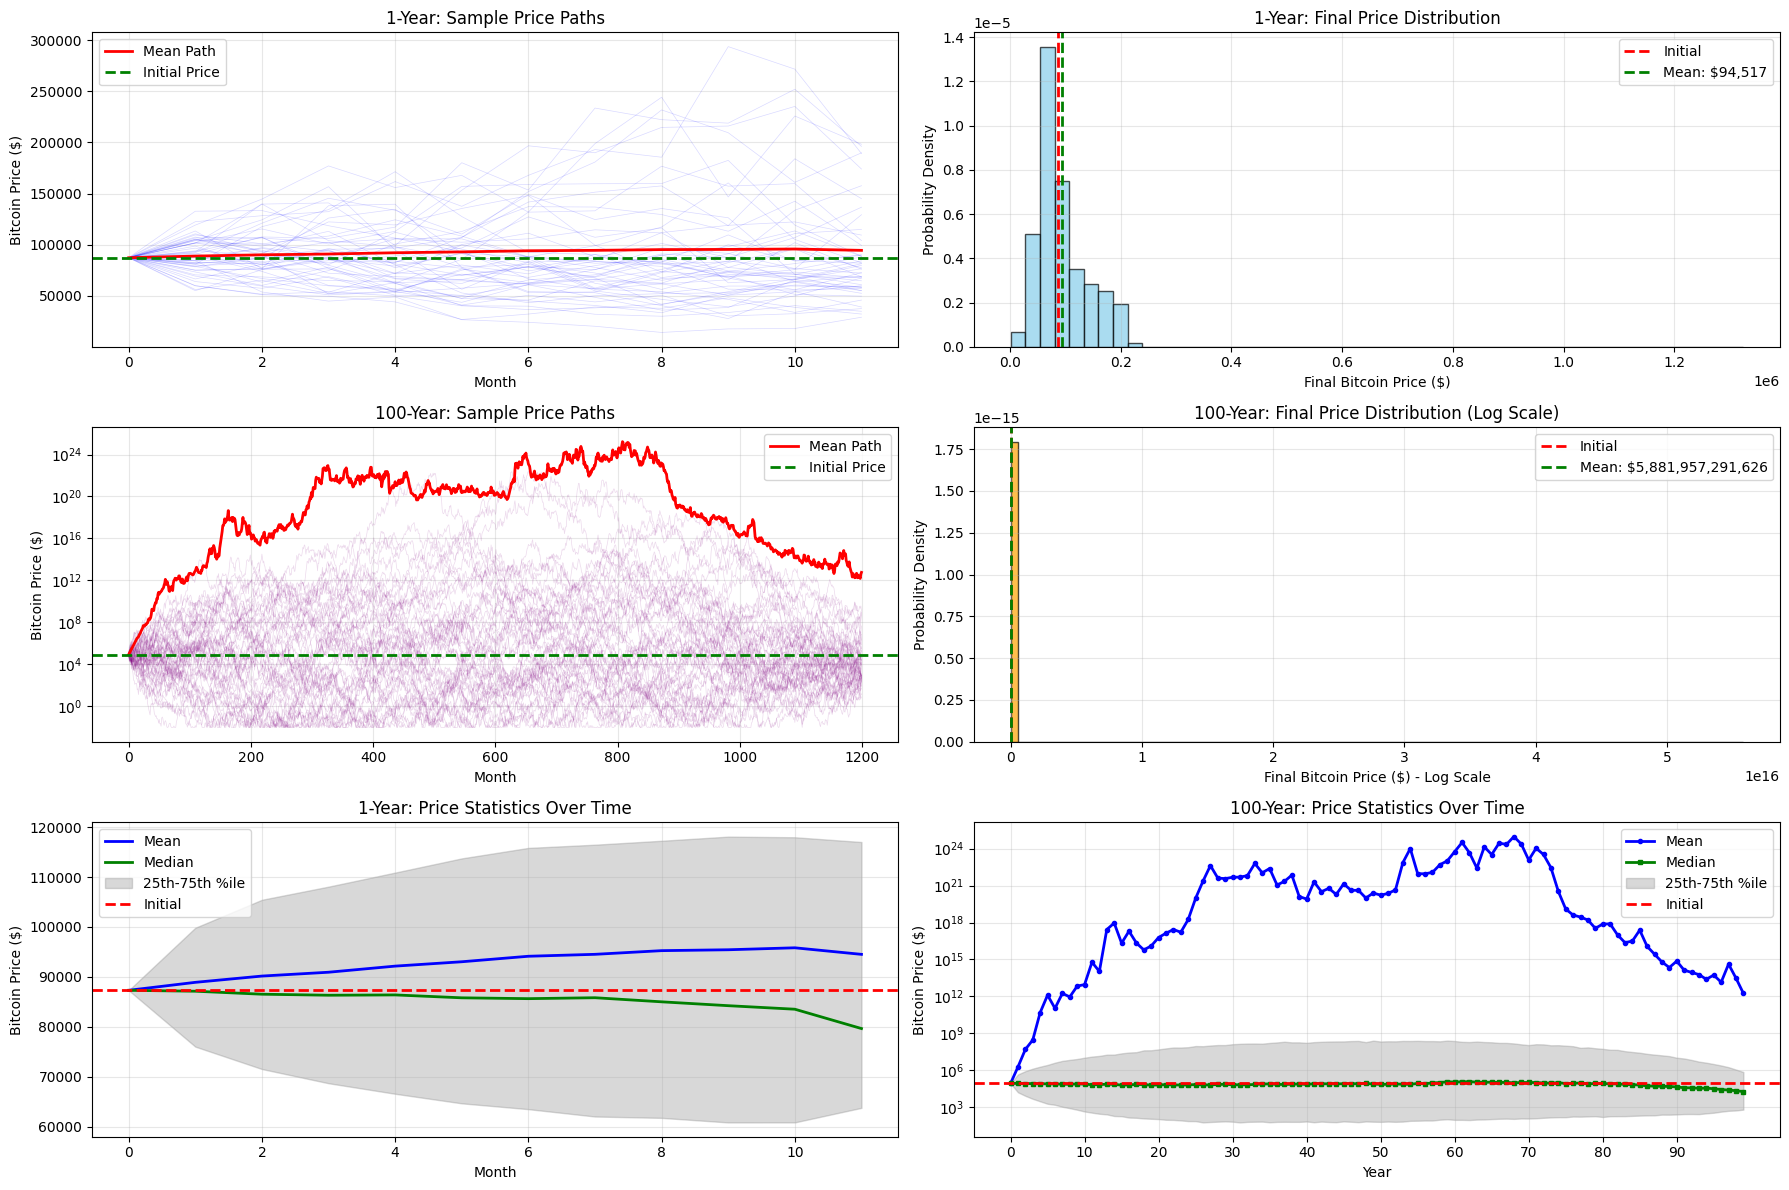

In [296]:
# ============================================================================
# VISUALIZE RESULTS (1-YEAR AND 100-YEAR)
# ============================================================================

fig = plt.figure(figsize=(18, 12))

# Row 1: 1-Year Simulation
# 1. Sample 1-year price paths
ax1 = plt.subplot(3, 2, 1)
sample_paths = min(50, NUM_SIMULATIONS)
for i in range(sample_paths):
    ax1.plot(simulated_prices_1yr[i, :], alpha=0.15, linewidth=0.5, color='blue')
ax1.plot(simulated_prices_1yr.mean(axis=0), 'r-', linewidth=2, label='Mean Path')
ax1.axhline(y=CURRENT_BTC_PRICE, color='g', linestyle='--', linewidth=2, label='Initial Price')
ax1.set_xlabel('Month')
ax1.set_ylabel('Bitcoin Price ($)')
ax1.set_title('1-Year: Sample Price Paths')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. 1-year final price distribution
ax2 = plt.subplot(3, 2, 2)
ax2.hist(final_prices_1yr, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black')
ax2.axvline(x=CURRENT_BTC_PRICE, color='r', linestyle='--', linewidth=2, label='Initial')
ax2.axvline(x=final_prices_1yr.mean(), color='g', linestyle='--', linewidth=2, label=f'Mean: ${final_prices_1yr.mean():,.0f}')
ax2.set_xlabel('Final Bitcoin Price ($)')
ax2.set_ylabel('Probability Density')
ax2.set_title('1-Year: Final Price Distribution')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Row 2: 100-Year Simulation
        # 3. Sample 100-year price paths
ax3 = plt.subplot(3, 2, 3)
sample_paths = min(50, NUM_SIMULATIONS)
for i in range(sample_paths):
    ax3.semilogy(simulated_prices_100yr[i, :], alpha=0.15, linewidth=0.5, color='purple')
ax3.semilogy(simulated_prices_100yr.mean(axis=0), 'r-', linewidth=2, label='Mean Path')
ax3.axhline(y=CURRENT_BTC_PRICE, color='g', linestyle='--', linewidth=2, label='Initial Price')
ax3.set_xlabel('Month')
ax3.set_ylabel('Bitcoin Price ($)')
ax3.set_title('100-Year: Sample Price Paths')
ax3.legend()
ax3.grid(True, alpha=0.3)

# 4. 100-year final price distribution
ax4 = plt.subplot(3, 2, 4)
ax4.hist(final_prices_100yr, bins=100, density=True, alpha=0.7, color='orange', edgecolor='black')
ax4.axvline(x=CURRENT_BTC_PRICE, color='r', linestyle='--', linewidth=2, label='Initial')
ax4.axvline(x=final_prices_100yr.mean(), color='g', linestyle='--', linewidth=2, 
            label=f'Mean: ${final_prices_100yr.mean():,.0f}')
ax4.set_xlabel('Final Bitcoin Price ($) - Log Scale')
ax4.set_ylabel('Probability Density')
ax4.set_title('100-Year: Final Price Distribution (Log Scale)')
ax4.legend()
ax4.grid(True, alpha=0.3)

# Row 3: Statistics Over Time
# 5. 1-year statistics over time
ax5 = plt.subplot(3, 2, 5)
months_1yr = simulated_prices_1yr.shape[1]
mean_path_1yr = simulated_prices_1yr.mean(axis=0)
median_path_1yr = np.median(simulated_prices_1yr, axis=0)
p25_path_1yr = np.percentile(simulated_prices_1yr, 25, axis=0)
p75_path_1yr = np.percentile(simulated_prices_1yr, 75, axis=0)

ax5.plot(mean_path_1yr, 'b-', linewidth=2, label='Mean')
ax5.plot(median_path_1yr, 'g-', linewidth=2, label='Median')
ax5.fill_between(range(months_1yr), p25_path_1yr, p75_path_1yr, alpha=0.3, color='gray', label='25th-75th %ile')
ax5.axhline(y=CURRENT_BTC_PRICE, color='r', linestyle='--', linewidth=2, label='Initial')
ax5.set_xlabel('Month')
ax5.set_ylabel('Bitcoin Price ($)')
ax5.set_title('1-Year: Price Statistics Over Time')
ax5.legend()
ax5.grid(True, alpha=0.3)

        # 6. 100-year statistics over time (sampled)
ax6 = plt.subplot(3, 2, 6)
months_100yr = simulated_prices_100yr.shape[1]
# Sample every 12 months for clarity
sample_months = np.arange(0, months_100yr, 12)
mean_path_100yr = simulated_prices_100yr.mean(axis=0)
median_path_100yr = np.median(simulated_prices_100yr, axis=0)
p25_path_100yr = np.percentile(simulated_prices_100yr, 25, axis=0)
p75_path_100yr = np.percentile(simulated_prices_100yr, 75, axis=0)

ax6.semilogy(sample_months, mean_path_100yr[sample_months], 'b-', linewidth=2, label='Mean', marker='o', markersize=3)
ax6.semilogy(sample_months, median_path_100yr[sample_months], 'g-', linewidth=2, label='Median', marker='s', markersize=3)
ax6.fill_between(sample_months, p25_path_100yr[sample_months], p75_path_100yr[sample_months], 
                 alpha=0.3, color='gray', label='25th-75th %ile')
ax6.axhline(y=CURRENT_BTC_PRICE, color='r', linestyle='--', linewidth=2, label='Initial')
ax6.set_xlabel('Year')
ax6.set_ylabel('Bitcoin Price ($)')
ax6.set_title('100-Year: Price Statistics Over Time')
ax6.set_xticks(sample_months[::10])
ax6.set_xticklabels([f'{m//12}' for m in sample_months[::10]])
ax6.legend()
ax6.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
